# M11.12 — Final Mondrian conformal evaluation

**cal = fit · val = selection · test = final evaluation.**

El predictor M11 está congelado. Cal (30 000) ajusta bins, taxonomías y cuantiles
conformales desde cero. Val (40 000) evalúa todo el grid y determina la configuración
por label/política. Test (30 000) evalúa exclusivamente los sistemas seleccionados
con val, sin reelección ni reajuste de calibradores.

Se conservan grid, umbrales, cuantiles, taxonomías y rankings de M10. La separación
selección/evaluación es un cambio explícito respecto a M10, que seleccionaba con test.
Se mantienen candidatos estrictos y `no_strict_candidate`, sin fallback.
No se modifica el predictor ni se ejecuta entrenamiento, inferencia CNN, GPU o eventos reales.

Ejecutar por secciones. La búsqueda KNN del grid CPU puede ser costosa. El notebook
se entrega sin ejecutar el grid completo. La val del predictor puede haber sido usada
para elegir su checkpoint: esta separación protege test de la selección conformal,
no convierte val en un nuevo conjunto independiente del desarrollo del predictor.

## 1. Imports y paths

In [8]:
from pathlib import Path
import sys
import json
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

root = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "src/paths.py").is_file()), None)

if root is None:
    raise RuntimeError("Abrir el notebook desde el repositorio cbc_pe.")

if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from src.paths import resolve_project_root, resolve_data_root, resolve_processed_artifact

PROJECT_ROOT = resolve_project_root()
DATA_ROOT = resolve_data_root(config_data_root="/data/vserrano/cbc_pe_data")
DATASET_ID = "M11_final_G1_500k"
LABEL_NAMES = ["chirp_mass", "total_mass", "chi_eff"]
DATASET_PATH = resolve_processed_artifact(
    data_root=DATA_ROOT, dataset_id=DATASET_ID,
    file_name="m11_final_G1_500k_trainio.h5", allow_legacy_flat=False)
RESULTS_DIR = DATA_ROOT / "results" / DATASET_ID
FIGURES_DIR = RESULTS_DIR / "M11_12_final_mondrian_evaluation" / "figures_cal_val_test"
PREDICTIONS_PATH = RESULTS_DIR / "m11_final_G1_500k_cal_test_predictions_embeddings.npz"


VAL_PREDICTIONS_PATH = RESULTS_DIR / "m11_final_G1_500k_val_predictions_embeddings.npz"

M10_RESULTS_DIR = DATA_ROOT / "results" / "mondrian_M10_final_baseline"
M10_SELECTED_PATH = M10_RESULTS_DIR / "selected_systems_summary.csv"
CONFIDENCE_LEVEL = 0.90
N_BINS_GRID = [4, 6, 8, 12, 16, 24, 32, 48]
TAXONOMY_MODES = ["prediction", "difficulty"]
INTERVAL_MODES = ["symmetric", "asymmetric"]
N_NEIGHBORS = 5
MIN_SAMPLES_PER_BIN = 20
print("DATA_ROOT:", DATA_ROOT)
print("PREDICTIONS_PATH:", PREDICTIONS_PATH)
print("RESULTS_DIR:", RESULTS_DIR)
if not PREDICTIONS_PATH.is_file():
    raise FileNotFoundError(f"Editar PREDICTIONS_PATH: {PREDICTIONS_PATH}")

DATA_ROOT: /data/vserrano/cbc_pe_data
PREDICTIONS_PATH: /data/vserrano/cbc_pe_data/results/M11_final_G1_500k/m11_final_G1_500k_cal_test_predictions_embeddings.npz
RESULTS_DIR: /data/vserrano/cbc_pe_data/results/M11_final_G1_500k


## 2. Load cal+test y val prediction artifacts

Los nombres de los NPZ corresponden a las configuraciones de predicción cal+test
y val. `VAL_PREDICTIONS_PATH` es editable; se validan ambos artefactos al cargar.
El NPZ val esperado es `m11_final_G1_500k_val_predictions_embeddings.npz`.
Se inspeccionan sus claves al cargarlo, sin inventar ni reconstruir predicciones.
Se exige mismo checkpoint, dataset, split, scaler train-only, model_config y
normalización, y splits cal/val/test únicos y disjuntos. `allow_pickle=True`
sólo permite leer provenance de artefactos propios de confianza.
Cargar/verificar test no produce métricas ni interviene en selección.

In [9]:
def require(condition, message):
    if not condition:
        raise ValueError(message)

with np.load(PREDICTIONS_PATH, allow_pickle=True) as z:
    required = {"y_mean", "y_std", "label_names", "checkpoint_file", "dataset_path",
                "split_path", "label_stats_path", "model_config", "input_normalization",
                "available_splits", "pred_cal", "emb_cal", "y_cal", "idx_cal",
                "pred_test", "emb_test", "y_test", "idx_test"}
    require(required.issubset(z.files), f"Faltan claves: {sorted(required - set(z.files))}")
    print("NPZ keys:", z.files)
    label_names = z["label_names"].tolist()
    require(label_names == LABEL_NAMES, f"Orden de labels incorrecto: {label_names}")
    y_mean, y_std = np.asarray(z["y_mean"], dtype=float), np.asarray(z["y_std"], dtype=float)
    idx_cal, idx_test = z["idx_cal"].copy(), z["idx_test"].copy()
    y_cal, pred_cal = z["y_cal"].copy(), z["pred_cal"].copy()
    y_test, pred_test = z["y_test"].copy(), z["pred_test"].copy()
    require(set(z["available_splits"].tolist()) == {"cal", "test"}, "Splits inesperados")
    provenance = {key: z[key].item() for key in
                  ("checkpoint_file", "dataset_path", "split_path", "label_stats_path",
                   "model_config", "input_normalization")}

require(y_mean.shape == y_std.shape == (3,), "Shape del scaler incorrecto")
require(np.isfinite(y_mean).all() and np.isfinite(y_std).all() and (y_std > 0).all(),
        "Scaler no finito o desviaciones no positivas")
for name, values in [("y_cal", y_cal), ("pred_cal", pred_cal),
                     ("y_test", y_test), ("pred_test", pred_test)]:
    require(values.shape == (30000, 3), f"Shape incorrecto: {name}")
    require(np.isfinite(values).all(), f"NaN/Inf: {name}")
for name, indices in [("cal", idx_cal), ("test", idx_test)]:
    require(indices.shape == (30000,) and np.issubdtype(indices.dtype, np.integer),
            f"Índices incorrectos: {name}")
    require(len(np.unique(indices)) == 30000, f"Índices repetidos: {name}")
    require(np.all((indices >= 0) & (indices < 500000)), f"Índices fuera de rango: {name}")
require(np.intersect1d(idx_cal, idx_test).size == 0, "Cal y test se solapan")
require(provenance["model_config"]["dataset_id"] == DATASET_ID, "Dataset del artefacto incorrecto")
require(provenance["model_config"]["label_names"] == LABEL_NAMES, "Labels de provenance incorrectos")
require(provenance["input_normalization"] == dict(enabled=False, already_normalized=True,
    mode="per_sample_per_detector_zscore", eps=1e-6), "Contrato de normalización inesperado")
print(json.dumps(provenance, indent=2))
display(pd.DataFrame({"label": LABEL_NAMES, "train_y_mean": y_mean, "train_y_std": y_std}))
with np.load(PREDICTIONS_PATH, allow_pickle=False) as z:
    emb_cal = np.asarray(z["emb_cal"], dtype=float)
    emb_test = np.asarray(z["emb_test"], dtype=float)
embedding_dim = provenance["model_config"]["model_kwargs"]["embedding_dim"]
for name, embedding in [("cal", emb_cal), ("test", emb_test)]:
    require(embedding.shape == (30000, embedding_dim), f"Shape embedding {name}")
    require(np.isfinite(embedding).all(), f"Embedding no finito: {name}")
SPLITS = {
    "cal": dict(idx=idx_cal, pred=np.asarray(pred_cal, dtype=float),
                y=np.asarray(y_cal, dtype=float), emb=emb_cal),
    "test": dict(idx=idx_test, pred=np.asarray(pred_test, dtype=float),
                 y=np.asarray(y_test, dtype=float), emb=emb_test),
}
pred_cal, y_cal = SPLITS["cal"]["pred"], SPLITS["cal"]["y"]
pred_test, y_test = SPLITS["test"]["pred"], SPLITS["test"]["y"]
print("Validated:", {k: {name: arr.shape for name, arr in v.items()} for k, v in SPLITS.items()})

if not VAL_PREDICTIONS_PATH.is_file():
    raise FileNotFoundError(f"Falta NPZ val; copiar el artefacto o editar VAL_PREDICTIONS_PATH: {VAL_PREDICTIONS_PATH}")
with np.load(VAL_PREDICTIONS_PATH, allow_pickle=True) as z:
    print("VAL NPZ keys:", z.files)
    val_required = {"pred_val", "y_val", "emb_val", "idx_val", "label_names",
                    "y_mean", "y_std", "available_splits", *provenance.keys()}
    require(val_required.issubset(z.files), f"Faltan claves val: {sorted(val_required - set(z.files))}")
    require(z["label_names"].tolist() == LABEL_NAMES, "Labels val incompatibles")
    require(set(z["available_splits"].tolist()) == {"val"}, "Splits NPZ val inesperados")
    require(np.array_equal(z["y_mean"], y_mean) and np.array_equal(z["y_std"], y_std),
            "Scaler val distinto del scaler cal+test")
    val_provenance = {key: z[key].item() for key in provenance}
    for key in provenance:
        require(val_provenance[key] == provenance[key], f"Provenance val incompatible: {key}")
    pred_val = np.asarray(z["pred_val"], dtype=float)
    y_val = np.asarray(z["y_val"], dtype=float)
    emb_val = np.asarray(z["emb_val"], dtype=float)
    idx_val = z["idx_val"].copy()
for name, values, shape in [("pred_val", pred_val, (40000, 3)),
                             ("y_val", y_val, (40000, 3)),
                             ("emb_val", emb_val, (40000, embedding_dim))]:
    require(values.shape == shape and np.isfinite(values).all(), f"Shape/finite incorrecto: {name}")
require(idx_val.shape == (40000,) and np.issubdtype(idx_val.dtype, np.integer), "Índices val incorrectos")
require(len(np.unique(idx_val)) == 40000, "Índices val repetidos")
require(np.all((idx_val >= 0) & (idx_val < 500000)), "Índices val fuera de rango")
for split, indices in [("cal", idx_cal), ("test", idx_test)]:
    require(np.intersect1d(idx_val, indices).size == 0, f"Val y {split} se solapan")
SPLITS["val"] = dict(idx=idx_val, pred=pred_val, y=y_val, emb=emb_val)
print("Validated val:", {name: arr.shape for name, arr in SPLITS["val"].items()})

NPZ keys: ['y_mean', 'y_std', 'label_names', 'checkpoint_file', 'dataset_path', 'split_path', 'label_stats_path', 'model_config', 'input_normalization', 'available_splits', 'pred_cal', 'emb_cal', 'y_cal', 'idx_cal', 'pred_test', 'emb_test', 'y_test', 'idx_test']
{
  "checkpoint_file": "/data/vserrano/cbc_pe_data/models/checkpoints/M11_final_G1_500k/M11_final_G1_500k_SimpleCNN_ResidualDilated_M11_final_G1_inputzscore_resdilated_emb64_d124_train400k_MSELoss_seed123_checkpoint.pt",
  "dataset_path": "/data/vserrano/cbc_pe_data/processed/M11_final_G1_500k/m11_final_G1_500k_trainio.h5",
  "split_path": "/data/vserrano/cbc_pe_data/processed/M11_final_G1_500k/M11_final_G1_500k_splits_train400000_val40000_cal30000_test30000_seed123.npz",
  "label_stats_path": "/data/vserrano/cbc_pe_data/processed/M11_final_G1_500k/M11_final_G1_500k_label_stats_train_only_train400000_val40000_cal30000_test30000_seed123.npz",
  "model_config": {
    "architecture": "SimpleCNN_ResidualDilated",
    "class_name": 

,label,train_y_mean,train_y_std
0,chirp_mass,37.463547,16.508060
1,total_mass,94.985977,34.703293
2,chi_eff,-0.000219,0.440338


Validated: {'cal': {'idx': (30000,), 'pred': (30000, 3), 'y': (30000, 3), 'emb': (30000, 64)}, 'test': {'idx': (30000,), 'pred': (30000, 3), 'y': (30000, 3), 'emb': (30000, 64)}}
VAL NPZ keys: ['y_mean', 'y_std', 'label_names', 'checkpoint_file', 'dataset_path', 'split_path', 'label_stats_path', 'model_config', 'input_normalization', 'available_splits', 'pred_val', 'emb_val', 'y_val', 'idx_val']
Validated val: {'idx': (40000,), 'pred': (40000, 3), 'y': (40000, 3), 'emb': (40000, 64)}


## 3. Inverse transform y espacio de calibración

M10 calibra **en espacio estandarizado**, con arrays convertidos a float64.
Se conserva exactamente esa política. Los targets/predicciones físicos se obtienen
con `physical = standardized * y_std + y_mean`; los anchos se multiplican por
`y_std` (sin sumar la media). Las estadísticas train-only vienen del propio NPZ M11.

In [10]:
def inverse_standardize(values):
    return values * y_std + y_mean

y_cal_phys = inverse_standardize(y_cal)
pred_cal_phys = inverse_standardize(pred_cal)
y_test_phys = inverse_standardize(y_test)
pred_test_phys = inverse_standardize(pred_test)
for values in (y_cal_phys, pred_cal_phys, y_test_phys, pred_test_phys):
    require(values.shape == (30000, 3) and np.isfinite(values).all(), "Inverse transform inválido")
y_val_phys = inverse_standardize(y_val)
pred_val_phys = inverse_standardize(pred_val)
for values in (y_val_phys, pred_val_phys):
    require(values.shape == (40000, 3) and np.isfinite(values).all(), "Inverse transform val inválido")

## 4. Contrato M10 reutilizado y limitaciones

Se reutiliza `src.conformal.pipeline.run_mondrian_regression` para cal→val,
y `FittedMondrianRegressor` / `apply_mondrian` / `evaluate_mondrian` para aplicar
el estado cal ya ajustado a test, sin refit. No se modifica ningún módulo:
`taxonomy`, `DifficultyEstimator`, `QuantileBinner`, `BinGrouper`,
`ConformalIntervalCalibrator`, `apply_indices` y `CoverageEvaluator` son los de M10.
Los helpers que sólo existen en el notebook M10 se copian localmente.

- **Prediction:** bins por predicción de cada label.
- **Difficulty:** media de residuos absolutos cal por label entre 5 vecinos en
  embeddings cal, distancia euclídea, pesos normalizados `1/(distance + 1e-8)`.
  No estandariza embeddings. Para cal consulta 6 vecinos y elimina el primero;
  para val y test consulta 5 vecinos cal. No usa targets val/test para difficulty.
  La referencia ajustada conserva únicamente embeddings y residuos cal; nunca val/test.
- **Bins:** cuantiles cal `linspace(0,1,n_bins+1)`, jitter uniforme ±`1e-10`
  sólo al ajustar bordes; asignación con bordes internos y `digitize(right=False)`.
  M10 no fija semilla para ese `default_rng`; se conserva esa no determinación.
- **Symmetric:** ordena `abs(y-pred)`, toma índice base cero
  `clip(ceil((m+1)*0.90)-1, 0, m-1)` y offsets `[-q,+q]`.
- **Asymmetric:** ordena `y-pred`, α=0.10; índices base cero
  `k_low=clip(floor((m+1)*α/2),0,m-1)` y
  `k_high=clip(ceil((m+1)*(1-α/2))-1,0,m-1)`;
  límites `pred + residual[k_low/k_high]`, sin percentiles interpolados.
- Se conservan mínimo **20 residuos cal/bin**, errores por bins insuficientes,
  warnings por bordes degenerados y estadísticos extremos. Bandas nominales:
  `clip(0.90 ± k*sqrt(0.90*0.10/n),0,1)`, k=1,2,3, con **counts val para selección y counts test para evaluación final**.
  Undercoverage 2σ significa coverage estrictamente menor que el límite inferior.

**Problemas heredados, documentados sin corregir:** el índice inferior asimétrico
es una posición mayor que `floor((m+1)*α/2)-1` en base cero; por tanto no debe
atribuirse a esta implementación una garantía exacta conservadora por cola.
Los índices extremos además se recortan al rango observado. La exclusión del propio
vecino elimina la primera posición, no busca su ID; embeddings duplicados pueden
invalidar esa exclusión. Difficulty aprende la taxonomía con los mismos residuos
cal usados para calibrar: este análisis no demuestra una garantía de cobertura
condicional finita para esa taxonomía adaptativa. No se corrigen estos puntos,
no se cambian semillas y no se relajan filtros. La selección se realiza exclusivamente sobre val. No reutilizamos calibradores ni ganadores M10.

## 5. Global conformal baseline — referencia cal→val, fuera de selección

Baseline M10 con cuantiles cal y evaluación val. No se usa para seleccionar ni se
evalúa en test: test se reserva para las configuraciones Mondrian seleccionadas.

In [11]:
def conformal_order_statistic(values, confidence_level):
    values = np.sort(np.asarray(values))
    n = len(values)
    k = int(np.ceil((n + 1) * confidence_level)) - 1
    k = int(np.clip(k, 0, n - 1))
    return values[k]


def global_symmetric_conformal(pred_cal, y_cal, pred_test, y_test, confidence_level):
    n_labels = y_cal.shape[1]
    lower = np.empty_like(pred_test)
    upper = np.empty_like(pred_test)
    quantiles = np.empty(n_labels)

    for j in range(n_labels):
        scores = np.abs(y_cal[:, j] - pred_cal[:, j])
        q = conformal_order_statistic(scores, confidence_level)
        quantiles[j] = q
        lower[:, j] = pred_test[:, j] - q
        upper[:, j] = pred_test[:, j] + q

    covered = (y_test >= lower) & (y_test <= upper)
    widths = upper - lower

    return {
        "lower": lower,
        "upper": upper,
        "quantiles": quantiles,
        "covered": covered,
        "widths": widths,
    }


GLOBAL_CONFORMAL = global_symmetric_conformal(
    pred_cal=SPLITS["cal"]["pred"],
    y_cal=SPLITS["cal"]["y"],
    pred_test=SPLITS["val"]["pred"],
    y_test=SPLITS["val"]["y"],
    confidence_level=CONFIDENCE_LEVEL,
)

global_rows = []
widths_phys = GLOBAL_CONFORMAL["widths"] * y_std

for j, label in enumerate(label_names):
    global_rows.append({
        "label": label,
        "coverage": float(GLOBAL_CONFORMAL["covered"][:, j].mean()),
        "mean_width_phys": float(np.mean(widths_phys[:, j])),
        "median_width_phys": float(np.median(widths_phys[:, j])),
        "q90_width_phys": float(np.quantile(widths_phys[:, j], 0.90)),
        "q95_width_phys": float(np.quantile(widths_phys[:, j], 0.95)),
        "score_quantile_std": float(GLOBAL_CONFORMAL["quantiles"][j]),
    })

global_conformal_df = pd.DataFrame(global_rows)
display(global_conformal_df)
global_conformal_df["evaluation_split"] = "val"

,label,coverage,mean_width_phys,median_width_phys,q90_width_phys,q95_width_phys,score_quantile_std
0,chirp_mass,0.89985,17.644196,17.644196,17.644196,17.644196,0.534412
1,total_mass,0.90210,31.889922,31.889922,31.889922,31.889922,0.459465
2,chi_eff,0.90155,0.623971,0.623971,0.623971,0.623971,0.708513


## 6. Mondrian grid — cal fit, val evaluation

32 configuraciones conjuntas, 96 filas label/configuración. El argumento histórico
`pred_test/y_test` del wrapper recibe **val**, no test. Todos los bins, residuos,
cuantiles y referencias KNN proceden únicamente de cal. `summary_df` y `all_results`
son exclusivamente de val y se conservan íntegros. Se guarda también el estado
cal ajustado para aplicar después exactamente los mismos sistemas, sin refit.

In [12]:
def summarize_result(result, y_target, labels, scales, key, evaluation_split):
    taxonomy_mode, interval_mode, n_bins = key
    summary_rows = []
    metrics = result.metrics
    widths_std = result.upper - result.lower
    widths_phys = widths_std * scales

    for j, label in enumerate(labels):
        coverage_bin = metrics["coverage_per_bin"][:, j]
        count_bin = metrics["counts_per_bin"][:, j]
        valid_bins = count_bin > 0

        bin_tol = metrics["bin_tolerance_normal"]
        low_2s = bin_tol["2sigma_low"][:, j]
        high_2s = bin_tol["2sigma_high"][:, j]

        outside_2s = valid_bins & (
            (coverage_bin < low_2s)
            | (coverage_bin > high_2s)
        )
        under_2s = valid_bins & (coverage_bin < low_2s)
        over_2s = valid_bins & (coverage_bin > high_2s)

        covered = (
            (result.lower[:, j] <= y_target[:, j])
            & (y_target[:, j] <= result.upper[:, j])
        )

        lower_miss = y_target[:, j] < result.lower[:, j]
        upper_miss = y_target[:, j] > result.upper[:, j]

        lower_miss_rate = float(lower_miss.mean())
        upper_miss_rate = float(upper_miss.mean())

        summary_rows.append({
            "taxonomy_mode": taxonomy_mode,
            "interval_mode": interval_mode,
            "n_bins": int(n_bins),
            "label": label,
            "label_index": j,
            "evaluation_split": evaluation_split,

            "global_coverage": float(metrics["global_coverage"][j]),
            "global_miscoverage": float(1.0 - metrics["global_coverage"][j]),
            "global_undercoverage_pvalue": float(metrics["global_undercoverage_pvalue"][j]),

            "global_mean_width_std": float(np.mean(widths_std[:, j])),
            "global_median_width_std": float(np.median(widths_std[:, j])),
            "global_q90_width_std": float(np.quantile(widths_std[:, j], 0.90)),
            "global_q95_width_std": float(np.quantile(widths_std[:, j], 0.95)),

            "global_mean_width_phys": float(np.mean(widths_phys[:, j])),
            "global_median_width_phys": float(np.median(widths_phys[:, j])),
            "global_q90_width_phys": float(np.quantile(widths_phys[:, j], 0.90)),
            "global_q95_width_phys": float(np.quantile(widths_phys[:, j], 0.95)),
            "global_width_iqr_phys": float(
                np.quantile(widths_phys[:, j], 0.75)
                - np.quantile(widths_phys[:, j], 0.25)
            ),

            "min_coverage_per_bin": float(np.nanmin(coverage_bin[valid_bins])),
            "max_coverage_per_bin": float(np.nanmax(coverage_bin[valid_bins])),
            "max_undercoverage_gap": float(
                np.nanmax(np.maximum(0.0, CONFIDENCE_LEVEL - coverage_bin[valid_bins]))
            ),
            "min_count_per_bin": int(np.nanmin(count_bin[valid_bins])),
            "max_count_per_bin": int(np.nanmax(count_bin[valid_bins])),

            "n_bins_outside_2sigma": int(outside_2s.sum()),
            "outside_bin_fraction_2sigma": float(outside_2s.sum() / valid_bins.sum()),
            "n_bins_under_2sigma": int(under_2s.sum()),
            "under_bin_fraction_2sigma": float(under_2s.sum() / valid_bins.sum()),
            "n_bins_over_2sigma": int(over_2s.sum()),
            "over_bin_fraction_2sigma": float(over_2s.sum() / valid_bins.sum()),

            "min_bin_2sigma_low": float(np.nanmin(low_2s[valid_bins])),
            "max_bin_2sigma_high": float(np.nanmax(high_2s[valid_bins])),

            "lower_miss_rate": lower_miss_rate,
            "upper_miss_rate": upper_miss_rate,
            "global_tail_miss_imbalance": float(abs(lower_miss_rate - upper_miss_rate)),

            "global_1sigma_low": float(metrics["global_tolerance_normal"]["1sigma_low"][j]),
            "global_1sigma_high": float(metrics["global_tolerance_normal"]["1sigma_high"][j]),
            "global_2sigma_low": float(metrics["global_tolerance_normal"]["2sigma_low"][j]),
            "global_2sigma_high": float(metrics["global_tolerance_normal"]["2sigma_high"][j]),
            "global_3sigma_low": float(metrics["global_tolerance_normal"]["3sigma_low"][j]),
            "global_3sigma_high": float(metrics["global_tolerance_normal"]["3sigma_high"][j]),
            "global_within_2sigma": bool(
                (metrics["global_coverage"][j] >= metrics["global_tolerance_normal"]["2sigma_low"][j])
                and (metrics["global_coverage"][j] <= metrics["global_tolerance_normal"]["2sigma_high"][j])
            ),
        })

    return summary_rows

from types import SimpleNamespace
from src.conformal.pipeline import (
    run_mondrian_regression, FittedMondrianRegressor, MondrianPrediction,
    apply_mondrian, evaluate_mondrian,
)

all_results = {}
fitted_results = {}
summary_rows = []

pred_cal = SPLITS["cal"]["pred"]
y_cal = SPLITS["cal"]["y"]
emb_cal = SPLITS["cal"]["emb"]

pred_val = SPLITS["val"]["pred"]
y_val = SPLITS["val"]["y"]
emb_val = SPLITS["val"]["emb"]

for taxonomy_mode in TAXONOMY_MODES:
    for interval_mode in INTERVAL_MODES:
        for n_bins in N_BINS_GRID:
            kwargs = dict(
                pred_cal=pred_cal,
                pred_test=pred_val,
                y_cal=y_cal,
                y_test=y_val,
                n_bins=n_bins,
                confidence_level=CONFIDENCE_LEVEL,
                apply_jitter=True,
                interval_mode=interval_mode,
                taxonomy_mode=taxonomy_mode,
                min_samples_per_bin=MIN_SAMPLES_PER_BIN,
                tolerance_sigmas=(1, 2, 3),
            )

            if taxonomy_mode == "difficulty":
                kwargs.update(
                    cal_embedding=emb_cal,
                    target_embedding=emb_val,
                    n_neighbors=N_NEIGHBORS,
                )

            result = run_mondrian_regression(**kwargs)
            key = (taxonomy_mode, interval_mode, n_bins)
            all_results[key] = result

            fitted_results[key] = FittedMondrianRegressor(
                binner=result.binner, calibrator=result.calibrator,
                taxonomy_mode=taxonomy_mode, interval_mode=interval_mode,
                confidence_level=CONFIDENCE_LEVEL, n_bins=n_bins,
                bin_indices_cal=result.bin_indices_cal,
                grouped_residuals_cal=result.grouped_residuals_cal,
                binning_scores_cal=result.binning_scores_cal,
                difficulty_model=result.difficulty_model)
            summary_rows.extend(summarize_result(
                result, y_val, label_names, y_std, key, "val"))

summary_df = pd.DataFrame(summary_rows)
require(summary_df["evaluation_split"].eq("val").all(), "Selección requiere métricas val")
display(summary_df.head())
print("Number of val grid rows:", len(summary_df))

,taxonomy_mode,interval_mode,n_bins,label,label_index,evaluation_split,global_coverage,global_miscoverage,global_undercoverage_pvalue,global_mean_width_std,...,lower_miss_rate,upper_miss_rate,global_tail_miss_imbalance,global_1sigma_low,global_1sigma_high,global_2sigma_low,global_2sigma_high,global_3sigma_low,global_3sigma_high,global_within_2sigma
0,prediction,symmetric,4,chirp_mass,0,val,0.899725,0.100275,0.429694,1.007363,...,0.055075,0.045200,0.009875,0.8985,0.9015,0.897,0.903,0.8955,0.9045,True
1,prediction,symmetric,4,total_mass,1,val,0.900275,0.099725,0.575159,0.898606,...,0.049400,0.050325,0.000925,0.8985,0.9015,0.897,0.903,0.8955,0.9045,True
2,prediction,symmetric,4,chi_eff,2,val,0.902075,0.097925,0.918308,1.412549,...,0.046975,0.050950,0.003975,0.8985,0.9015,0.897,0.903,0.8955,0.9045,True
3,prediction,symmetric,6,chirp_mass,0,val,0.902000,0.098000,0.910440,1.014273,...,0.054900,0.043100,0.011800,0.8985,0.9015,0.897,0.903,0.8955,0.9045,True
4,prediction,symmetric,6,total_mass,1,val,0.902250,0.097750,0.934632,0.902293,...,0.048500,0.049250,0.000750,0.8985,0.9015,0.897,0.903,0.8955,0.9045,True


Number of val grid rows: 96


In [13]:
overview_cols = [
    "taxonomy_mode",
    "interval_mode",
    "n_bins",
    "label",
    "global_coverage",
    "min_coverage_per_bin",
    "n_bins_under_2sigma",
    "under_bin_fraction_2sigma",
    "max_undercoverage_gap",
    "global_median_width_phys",
    "global_q95_width_phys",
    "global_tail_miss_imbalance",
    "min_count_per_bin",
]

display(
    summary_df[overview_cols]
    .sort_values(["label", "global_median_width_phys"])
    .head(30)
)

grid_agg_df = (
    summary_df
    .groupby(["taxonomy_mode", "interval_mode", "label"], as_index=False)
    .agg(
        n_configs=("n_bins", "count"),
        median_coverage=("global_coverage", "median"),
        median_width_phys=("global_median_width_phys", "median"),
        min_width_phys=("global_median_width_phys", "min"),
        median_under_bins=("n_bins_under_2sigma", "median"),
        median_max_undercoverage_gap=("max_undercoverage_gap", "median"),
        median_tail_imbalance=("global_tail_miss_imbalance", "median"),
    )
)

display(grid_agg_df)

,taxonomy_mode,interval_mode,n_bins,label,global_coverage,min_coverage_per_bin,n_bins_under_2sigma,under_bin_fraction_2sigma,max_undercoverage_gap,global_median_width_phys,global_q95_width_phys,global_tail_miss_imbalance,min_count_per_bin
50,difficulty,symmetric,4,chi_eff,0.901475,0.898152,0,0.000000,0.001848,0.556532,0.816566,0.000675,9848
74,difficulty,asymmetric,4,chi_eff,0.900250,0.897746,0,0.000000,0.002254,0.556888,0.813604,0.004100,9848
80,difficulty,asymmetric,8,chi_eff,0.901175,0.894320,0,0.000000,0.005680,0.561770,0.941775,0.002975,4886
56,difficulty,symmetric,8,chi_eff,0.901150,0.894597,0,0.000000,0.005403,0.562616,0.939238,0.000250,4886
77,difficulty,asymmetric,6,chi_eff,0.900375,0.896050,0,0.000000,0.003950,0.562909,0.889728,0.003975,6532
53,difficulty,symmetric,6,chi_eff,0.901350,0.896203,0,0.000000,0.003797,0.563805,0.894767,0.000500,6532
59,difficulty,symmetric,12,chi_eff,0.900900,0.892076,0,0.000000,0.007924,0.576855,1.005337,0.000350,3219
83,difficulty,asymmetric,12,chi_eff,0.899850,0.892076,0,0.000000,0.007924,0.580988,1.009106,0.001850,3219
92,difficulty,asymmetric,32,chi_eff,0.901100,0.872549,4,0.125000,0.027451,0.581377,0.940055,0.001300,1136
71,difficulty,symmetric,48,chi_eff,0.901950,0.856651,4,0.083333,0.043349,0.581401,0.948762,0.001100,730


,taxonomy_mode,interval_mode,label,n_configs,median_coverage,median_width_phys,min_width_phys,median_under_bins,median_max_undercoverage_gap,median_tail_imbalance
0,difficulty,asymmetric,chi_eff,8,0.900788,0.581183,0.556888,0.5,0.012927,0.002137
1,difficulty,asymmetric,chirp_mass,8,0.899687,16.213381,15.892952,1.0,0.013495,0.002212
2,difficulty,asymmetric,total_mass,8,0.899163,27.658760,25.942144,3.0,0.018382,0.002687
3,difficulty,symmetric,chi_eff,8,0.901563,0.579128,0.556532,0.5,0.013360,0.000712
4,difficulty,symmetric,chirp_mass,8,0.900125,16.185356,16.014563,1.5,0.013930,0.005125
5,difficulty,symmetric,total_mass,8,0.899200,27.736408,25.914009,3.5,0.017530,0.008500
6,prediction,asymmetric,chi_eff,8,0.900725,0.661989,0.640721,2.0,0.014575,0.001725
7,prediction,asymmetric,chirp_mass,8,0.900025,18.004824,16.792328,2.5,0.016183,0.003863
8,prediction,asymmetric,total_mass,8,0.901000,28.814887,27.696938,3.0,0.014968,0.002562
9,prediction,symmetric,chi_eff,8,0.900462,0.663539,0.640026,2.0,0.014582,0.005425


## 7. Selection policy — candidatos estrictos, sin fallback

Se mantienen los umbrales y desempates de `src.conformal.selection`, sin modificar
ese módulo. Base: coverage global dentro de 2σ y mínimo 200 muestras val por bin
no vacío. Conservative estricto exige cero bins bajo 2σ. Efficient exige fracción
bajo 2σ ≤0.10 y gap ≤0.05. Se conserva el desempate de ancho del 2% y el ranking
original de cada política para sus candidatos admisibles.

Antes de invocar cada selector se comprueba su pool estricto. Si está vacío se
registra `no_strict_candidate` en `selection_status_df`; no se invoca el fallback
`conservative_best_available` ni el fallback efficient→conservative del módulo.
No se relajan thresholds ni se selecciona un sustituto. La tabla
`candidate_diagnostics_df` conserva todos los candidatos y muestra cada criterio.
`summary_df` y `all_results` permanecen íntegros. Los análisis de sistemas seleccionados
omiten únicamente las combinaciones label/política sin selección; el grid completo,
los diagnósticos, estados y CSV siguen disponibles aunque ninguna política seleccione.
La selección depende exclusivamente de val. Se conservan los rankings y thresholds
M10 sobre los pools estrictos; se mantiene la ausencia de fallback solicitada.
No se usa test para resolver ninguna ausencia de candidatos.

In [14]:
from src.conformal.selection import (
    select_conservative,
    select_efficient,
)

# ------------------------------------------------------------------
# M10 Mondrian selection policy applied to M11
# ------------------------------------------------------------------
# These values are part of the scientific definition of the closed
# M10 conformal baseline. They are passed explicitly rather than
# relying silently on the module defaults.
MIN_COUNT_PER_BIN = 200
WIDTH_TIE_FRACTION = 0.02
MAX_UNDER_BIN_FRACTION_EFFICIENT = 0.10
MAX_UNDERCOVERAGE_GAP_EFFICIENT = 0.05

# Presentation only: number of ranked alternatives retained for inspection.
TOP_K = 8


require(summary_df["evaluation_split"].eq("val").all(), "Sólo val puede alimentar selección")

selection_rows = []
top_rows = []
status_rows = []
diagnostic_rows = []

for label in label_names:
    candidates = summary_df.loc[summary_df["label"] == label].copy()
    candidates["passes_global_2sigma"] = candidates["global_within_2sigma"]
    candidates["passes_min_count"] = candidates["min_count_per_bin"] >= MIN_COUNT_PER_BIN
    base = candidates["passes_global_2sigma"] & candidates["passes_min_count"]
    candidates["passes_conservative_local"] = candidates["n_bins_under_2sigma"] == 0
    candidates["passes_efficient_fraction"] = (
        candidates["under_bin_fraction_2sigma"] <= MAX_UNDER_BIN_FRACTION_EFFICIENT)
    candidates["passes_efficient_gap"] = (
        candidates["max_undercoverage_gap"] <= MAX_UNDERCOVERAGE_GAP_EFFICIENT)
    candidates["strict_conservative"] = base & candidates["passes_conservative_local"]
    candidates["strict_efficient"] = (
        base & candidates["passes_efficient_fraction"] & candidates["passes_efficient_gap"])
    diagnostic_rows.append(candidates)

    for policy, selector in [("conservative", select_conservative),
                             ("efficient", select_efficient)]:
        strict = candidates.loc[candidates[f"strict_{policy}"], summary_df.columns]
        status_rows.append(dict(label=label, final_policy=policy,
            selection_status="selected" if not strict.empty else "no_strict_candidate",
            n_strict_candidates=len(strict)))
        if strict.empty:
            print(f"{label} / {policy}: no_strict_candidate (sin fallback)")
            continue
        kwargs = dict(min_count_per_bin=MIN_COUNT_PER_BIN,
                      width_tie_fraction=WIDTH_TIE_FRACTION)
        if policy == "efficient":
            kwargs.update(max_under_bin_fraction=MAX_UNDER_BIN_FRACTION_EFFICIENT,
                          max_undercoverage_gap=MAX_UNDERCOVERAGE_GAP_EFFICIENT)
        selected, ranked = selector(strict, label, **kwargs)
        selection_rows.append(dict(selected.to_dict(), final_policy=policy))
        top_rows.append(ranked.head(TOP_K).assign(label=label, final_policy=policy))

# Schemas remain usable even when no policy selects any system.
selection_columns = list(summary_df.columns) + [
    "min_width_for_label", "width_limit", "relative_width_excess",
    "selection_policy", "final_policy"]
selection_df = pd.DataFrame(selection_rows, columns=selection_columns)
top_candidates_df = (pd.concat(top_rows, ignore_index=True) if top_rows
                     else pd.DataFrame(columns=selection_columns))
selection_status_df = pd.DataFrame(status_rows)
candidate_diagnostics_df = pd.concat(diagnostic_rows, ignore_index=True)
display(selection_status_df)
diagnostic_cols = ["label", "taxonomy_mode", "interval_mode", "n_bins",
    "global_coverage", "global_2sigma_low", "global_2sigma_high", "min_count_per_bin",
    "n_bins_under_2sigma", "under_bin_fraction_2sigma", "max_undercoverage_gap",
    "global_median_width_phys", "passes_global_2sigma", "passes_min_count",
    "passes_conservative_local", "passes_efficient_fraction", "passes_efficient_gap",
    "strict_conservative", "strict_efficient"]
display(candidate_diagnostics_df[diagnostic_cols].sort_values(["label", "n_bins"]))


selection_display_cols = [
    "final_policy",
    "label",
    "selection_policy",
    "taxonomy_mode",
    "interval_mode",
    "n_bins",
    "global_coverage",
    "min_coverage_per_bin",
    "n_bins_under_2sigma",
    "under_bin_fraction_2sigma",
    "max_undercoverage_gap",
    "global_median_width_phys",
    "global_q90_width_phys",
    "global_q95_width_phys",
    "global_tail_miss_imbalance",
    "min_count_per_bin",
]


display(
    selection_df[selection_display_cols]
    .sort_values(["label", "final_policy"])
)
# Freeze the label/policy decisions before any test evaluation.
selected_from_val_df = selection_status_df.merge(
    selection_df, on=["label", "final_policy"], how="left", validate="one_to_one")
selected_from_val_df["selection_split"] = "val"
display(selected_from_val_df)

,label,final_policy,selection_status,n_strict_candidates
0,chirp_mass,conservative,selected,3
1,chirp_mass,efficient,selected,12
2,total_mass,conservative,selected,2
3,total_mass,efficient,selected,3
4,chi_eff,conservative,selected,12
5,chi_eff,efficient,selected,17


,label,taxonomy_mode,interval_mode,n_bins,global_coverage,global_2sigma_low,global_2sigma_high,min_count_per_bin,n_bins_under_2sigma,under_bin_fraction_2sigma,max_undercoverage_gap,global_median_width_phys,passes_global_2sigma,passes_min_count,passes_conservative_local,passes_efficient_fraction,passes_efficient_gap,strict_conservative,strict_efficient
64,chi_eff,prediction,symmetric,4,0.902075,0.897,0.903,9782,0,0.000000,0.001128,0.640026,True,True,True,True,True,True,True
72,chi_eff,prediction,asymmetric,4,0.902250,0.897,0.903,9782,0,0.000000,0.000930,0.640721,True,True,True,True,True,True,True
80,chi_eff,difficulty,symmetric,4,0.901475,0.897,0.903,9848,0,0.000000,0.001848,0.556532,True,True,True,True,True,True,True
88,chi_eff,difficulty,asymmetric,4,0.900250,0.897,0.903,9848,0,0.000000,0.002254,0.556888,True,True,True,True,True,True,True
65,chi_eff,prediction,symmetric,6,0.901650,0.897,0.903,6494,0,0.000000,0.001526,0.661317,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,total_mass,difficulty,asymmetric,32,0.899325,0.897,0.903,1137,5,0.156250,0.027592,28.491646,True,True,False,False,True,False,False
39,total_mass,prediction,symmetric,48,0.902100,0.897,0.903,734,7,0.145833,0.035845,29.598028,True,True,False,False,True,False,False
47,total_mass,prediction,asymmetric,48,0.900100,0.897,0.903,734,5,0.104167,0.033562,28.976553,True,True,False,False,True,False,False
55,total_mass,difficulty,symmetric,48,0.899875,0.897,0.903,741,9,0.187500,0.037037,28.926943,True,True,False,False,True,False,False


,final_policy,label,selection_policy,taxonomy_mode,interval_mode,n_bins,global_coverage,min_coverage_per_bin,n_bins_under_2sigma,under_bin_fraction_2sigma,max_undercoverage_gap,global_median_width_phys,global_q90_width_phys,global_q95_width_phys,global_tail_miss_imbalance,min_count_per_bin
4,conservative,chi_eff,conservative_zero_under_bins_2sigma,difficulty,symmetric,8,0.901150,0.894597,0,0.0000,0.005403,0.562616,0.939238,0.939238,0.000250,4886
5,efficient,chi_eff,efficient_local_validity_tolerant,difficulty,symmetric,4,0.901475,0.898152,0,0.0000,0.001848,0.556532,0.816566,0.816566,0.000675,9848
0,conservative,chirp_mass,conservative_zero_under_bins_2sigma,difficulty,asymmetric,16,0.899975,0.889248,0,0.0000,0.010752,16.185356,26.755825,37.546419,0.002825,2403
1,efficient,chirp_mass,efficient_local_validity_tolerant,difficulty,asymmetric,48,0.898850,0.872093,3,0.0625,0.027907,15.945123,27.219466,30.971286,0.000450,730
2,conservative,total_mass,conservative_zero_under_bins_2sigma,prediction,asymmetric,4,0.901650,0.896334,0,0.0000,0.003666,27.696938,37.025800,37.025800,0.003550,9774
3,efficient,total_mass,efficient_local_validity_tolerant,prediction,asymmetric,4,0.901650,0.896334,0,0.0000,0.003666,27.696938,37.025800,37.025800,0.003550,9774


,label,final_policy,selection_status,n_strict_candidates,taxonomy_mode,interval_mode,n_bins,label_index,evaluation_split,global_coverage,...,global_2sigma_low,global_2sigma_high,global_3sigma_low,global_3sigma_high,global_within_2sigma,min_width_for_label,width_limit,relative_width_excess,selection_policy,selection_split
0,chirp_mass,conservative,selected,3,difficulty,asymmetric,16,0,val,0.899975,...,0.897,0.903,0.8955,0.9045,True,16.185356,16.509063,0.000000,conservative_zero_under_bins_2sigma,val
1,chirp_mass,efficient,selected,12,difficulty,asymmetric,48,0,val,0.898850,...,0.897,0.903,0.8955,0.9045,True,15.945123,16.264026,0.000000,efficient_local_validity_tolerant,val
2,total_mass,conservative,selected,2,prediction,asymmetric,4,1,val,0.901650,...,0.897,0.903,0.8955,0.9045,True,27.696938,28.250877,0.000000,conservative_zero_under_bins_2sigma,val
3,total_mass,efficient,selected,3,prediction,asymmetric,4,1,val,0.901650,...,0.897,0.903,0.8955,0.9045,True,27.696938,28.250877,0.000000,efficient_local_validity_tolerant,val
4,chi_eff,conservative,selected,12,difficulty,symmetric,8,2,val,0.901150,...,0.897,0.903,0.8955,0.9045,True,0.556532,0.567662,0.010932,conservative_zero_under_bins_2sigma,val
5,chi_eff,efficient,selected,17,difficulty,symmetric,4,2,val,0.901475,...,0.897,0.903,0.8955,0.9045,True,0.556532,0.567662,0.000000,efficient_local_validity_tolerant,val


## 8. Test final — aplicar sistemas seleccionados en val, sin refit


In [15]:
# Only configurations chosen on val reach test; no selector is called here.
from copy import copy
from dataclasses import replace
test_results = {}
test_predictions = {}
final_rows = []
for _, selected in selection_df.iterrows():
    label = selected["label"]
    j = label_names.index(label)
    key = (selected["taxonomy_mode"], selected["interval_mode"], int(selected["n_bins"]))
    fitted = fitted_results[key]
    if key not in test_predictions:
        # Preserve val neighbor-cache diagnostics; the cal reference is not refitted.
        test_fitted = replace(fitted, difficulty_model=copy(fitted.difficulty_model))
        test_predictions[key] = apply_mondrian(
            test_fitted, pred_target=pred_test,
            target_embedding=emb_test if fitted.taxonomy_mode == "difficulty" else None)
    prediction = test_predictions[key]
    # The shared model returns all output columns; evaluate only the selected label.
    single = MondrianPrediction(
        lower=prediction.lower[:, j:j+1], upper=prediction.upper[:, j:j+1],
        bin_indices=prediction.bin_indices[:, j:j+1],
        binning_scores=prediction.binning_scores[:, j:j+1])
    metrics = evaluate_mondrian(fitted, single, y_test[:, j:j+1], tolerance_sigmas=(1, 2, 3))
    result = SimpleNamespace(lower=single.lower, upper=single.upper,
        bin_indices_test=single.bin_indices, metrics=metrics,
        bin_indices_cal=fitted.bin_indices_cal[:, j:j+1])
    test_results[(selected["final_policy"], label)] = result
    row = summarize_result(result, y_test[:, j:j+1], [label], y_std[j:j+1], key, "test")[0]
    row.update(label_index=j, final_policy=selected["final_policy"],
               selection_policy=selected["selection_policy"], selection_split="val")
    final_rows.append(row)

final_test_summary_df = pd.DataFrame(final_rows,
    columns=list(summary_df.columns) + ["final_policy", "selection_policy", "selection_split"])
# All six statuses are retained; missing selections have no test metrics/configuration.
final_test_evaluation_df = selection_status_df.merge(
    final_test_summary_df, on=["label", "final_policy"], how="left", validate="one_to_one")
final_test_evaluation_df["evaluation_split"] = "test"
final_test_evaluation_df["selection_split"] = "val"
display(final_test_evaluation_df)


,label,final_policy,selection_status,n_strict_candidates,taxonomy_mode,interval_mode,n_bins,label_index,evaluation_split,global_coverage,...,global_tail_miss_imbalance,global_1sigma_low,global_1sigma_high,global_2sigma_low,global_2sigma_high,global_3sigma_low,global_3sigma_high,global_within_2sigma,selection_policy,selection_split
0,chirp_mass,conservative,selected,3,difficulty,asymmetric,16,0,test,0.902500,...,0.001367,0.898268,0.901732,0.896536,0.903464,0.894804,0.905196,True,conservative_zero_under_bins_2sigma,val
1,chirp_mass,efficient,selected,12,difficulty,asymmetric,48,0,test,0.901600,...,0.001000,0.898268,0.901732,0.896536,0.903464,0.894804,0.905196,True,efficient_local_validity_tolerant,val
2,total_mass,conservative,selected,2,prediction,asymmetric,4,1,test,0.906667,...,0.004667,0.898268,0.901732,0.896536,0.903464,0.894804,0.905196,False,conservative_zero_under_bins_2sigma,val
3,total_mass,efficient,selected,3,prediction,asymmetric,4,1,test,0.906667,...,0.004667,0.898268,0.901732,0.896536,0.903464,0.894804,0.905196,False,efficient_local_validity_tolerant,val
4,chi_eff,conservative,selected,12,difficulty,symmetric,8,2,test,0.905233,...,0.001700,0.898268,0.901732,0.896536,0.903464,0.894804,0.905196,False,conservative_zero_under_bins_2sigma,val
5,chi_eff,efficient,selected,17,difficulty,symmetric,4,2,test,0.907100,...,0.000833,0.898268,0.901732,0.896536,0.903464,0.894804,0.905196,False,efficient_local_validity_tolerant,val


## 9. Final test bin stability diagnostics — selected on val

Todos los plots siguientes usan test y sólo los sistemas seleccionados con val.
No cambian decisiones, incluso si sus métricas test incumplen criterios de selección.

In [16]:
PALETTE = {
    "coverage": "#26578F",
    "coverage_dark": "#1A3553",
    "width": "#831616",
    "width_dark": "#5C0E0E",
    "nominal": "#252525",
    "band_1": "#60A4EC",
    "band_2": "#60A4EC",
    "band_3": "#60A4EC",
    "prediction": "#456990",
    "difficulty": "#7A5C99",
    "symmetric": "#2A9D8F",
    "asymmetric": "#E76F51",
    "ideal": "#B23A48",
    "median": "#B23A48",
    "density_cmap": "mako",  # fallback handled below if unavailable
}

# Matplotlib may not know "mako" unless seaborn is installed/registered.
# Fall back to a built-in perceptually smooth cmap.
try:
    plt.get_cmap(PALETTE["density_cmap"])
except ValueError:
    PALETTE["density_cmap"] = "viridis"

LABEL_TEX = {
    "chirp_mass": r"$\mathcal{M}$",
    "total_mass": r"$M_{\mathrm{tot}}$",
    "chi_eff": r"$\chi_{\mathrm{eff}}$",
}

LABEL_UNITS = {
    "chirp_mass": r"$M_\odot$",
    "total_mass": r"$M_\odot$",
    "chi_eff": "",
}

FIELD_TEX = {
    "network_snr": r"network SNR $\rho_{\mathrm{net}}$",
    "target_snr": r"target SNR $\rho_{\mathrm{target}}$",
    "signal_network_duration": r"signal duration $\Delta t_{\mathrm{GW}}$ [s]",
    "chirp_mass": r"true $\mathcal{M}$ [$M_\odot$]",
    "total_mass": r"true $M_{\mathrm{tot}}$ [$M_\odot$]",
    "chi_eff": r"true $\chi_{\mathrm{eff}}$",
    "distance": r"distance [Mpc]",
}


def label_tex(label):
    return LABEL_TEX.get(label, label)


def label_unit(label):
    return LABEL_UNITS.get(label, "")


def field_tex(field):
    return FIELD_TEX.get(field, field.replace("_", " "))


def style_axis(ax):
    ax.grid(True, alpha=0.25, linewidth=0.8)
    ax.tick_params(axis="both", labelsize=9)
    return ax

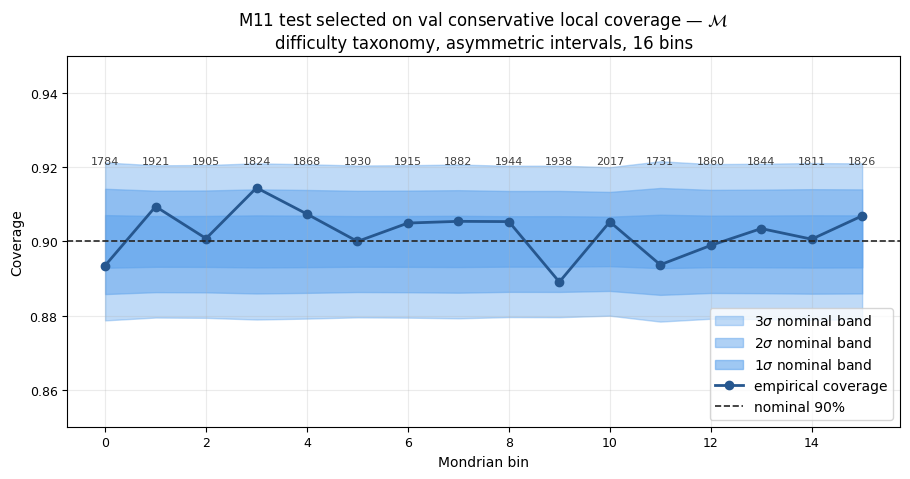

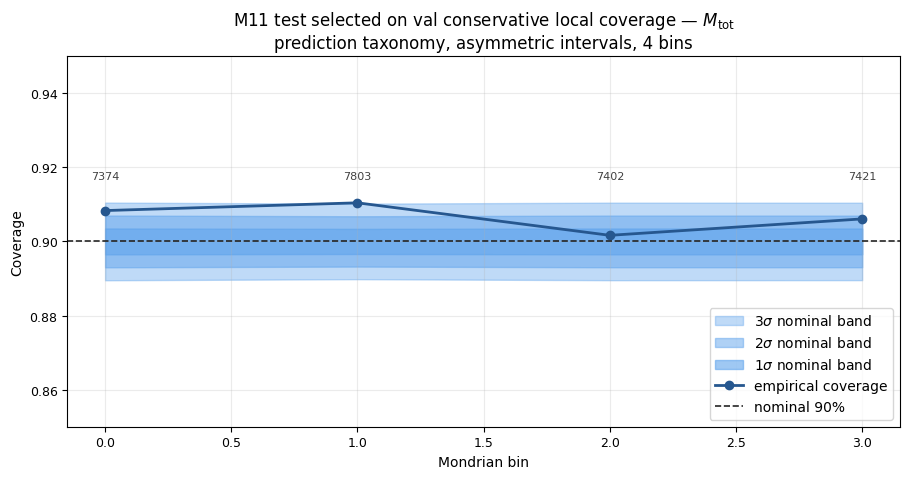

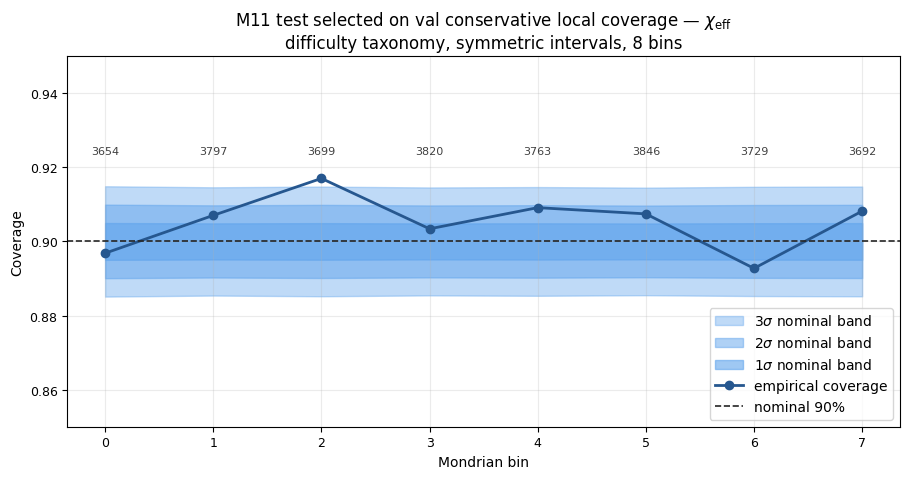

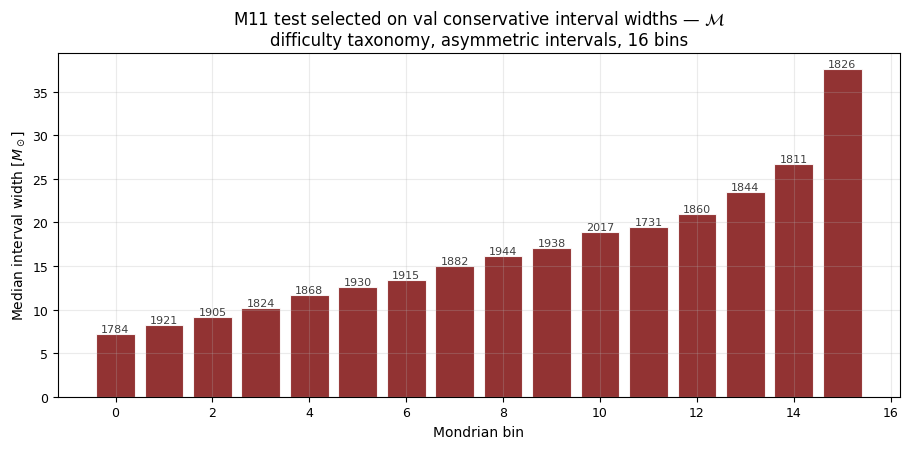

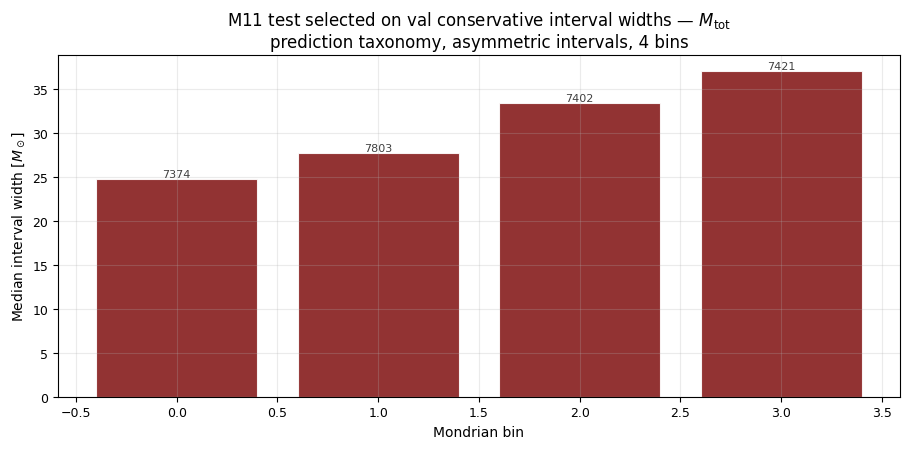

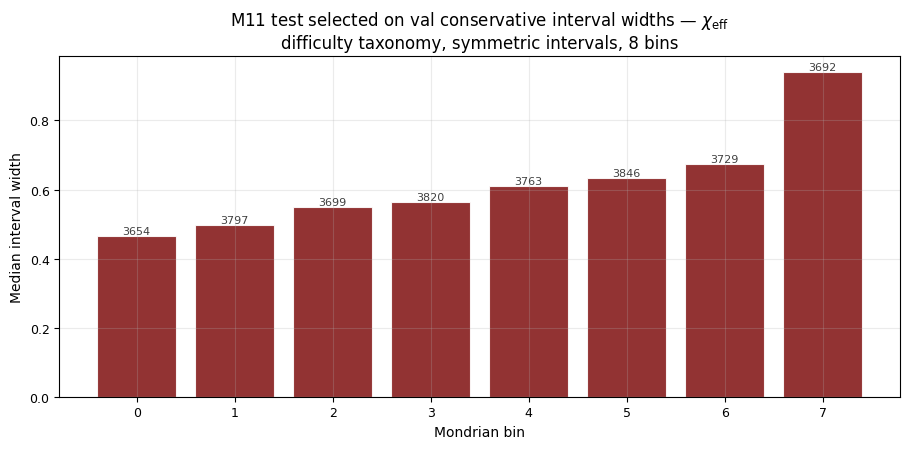

In [17]:
def get_selected_result(label, final_policy="conservative"):
    selected = final_test_summary_df[
        (final_test_summary_df["label"] == label)
        & (final_test_summary_df["final_policy"] == final_policy)]
    if selected.empty:
        return None, None
    return selected.iloc[0], test_results[(final_policy, label)]


def plot_selected_bin_coverage(final_policy="conservative"):
    for label in label_names:
        label_idx = label_names.index(label)
        row, result = get_selected_result(label, final_policy=final_policy)
        if result is None:
            continue
        metrics = result.metrics

        coverage = metrics["coverage_per_bin"][:, 0]
        counts = metrics["counts_per_bin"][:, 0]

        low_1s = metrics["bin_tolerance_normal"]["1sigma_low"][:, 0]
        high_1s = metrics["bin_tolerance_normal"]["1sigma_high"][:, 0]

        low_2s = metrics["bin_tolerance_normal"]["2sigma_low"][:, 0]
        high_2s = metrics["bin_tolerance_normal"]["2sigma_high"][:, 0]

        low_3s = metrics["bin_tolerance_normal"]["3sigma_low"][:, 0]
        high_3s = metrics["bin_tolerance_normal"]["3sigma_high"][:, 0]


        x = np.arange(len(coverage))

        fig, ax = plt.subplots(figsize=(9.2, 4.9))

        ax.fill_between(
            x,
            low_3s,
            high_3s,
            color=PALETTE["band_3"],
            alpha=0.40,
            label=r"$3\sigma$ nominal band",
        )

        ax.fill_between(
            x,
            low_2s,
            high_2s,
            color=PALETTE["band_2"],
            alpha=0.50,
            label=r"$2\sigma$ nominal band",
        )

        ax.fill_between(
            x,
            low_1s,
            high_1s,
            color=PALETTE["band_1"],
            alpha=0.60,
            label=r"$1\sigma$ nominal band",
        )
        ax.plot(
            x,
            coverage,
            marker="o",
            linewidth=2.0,
            color=PALETTE["coverage"],
            label="empirical coverage",
        )
        ax.axhline(
            CONFIDENCE_LEVEL,
            linestyle="--",
            color=PALETTE["nominal"],
            linewidth=1.2,
            label="nominal 90%",
        )

        for xi, n in zip(x, counts):
            ax.text(
                xi,
                min(0.995, max(coverage) + 0.006),
                f"{int(n)}",
                ha="center",
                va="bottom",
                fontsize=8,
                color="0.25",
            )

        ax.set_xlabel("Mondrian bin")
        ax.set_ylabel("Coverage")
        ax.set_title(
            f"M11 test selected on val {final_policy} local coverage — {label_tex(label)}\n"
            f"{row['taxonomy_mode']} taxonomy, {row['interval_mode']} intervals, {int(row['n_bins'])} bins"
        )
        ax.set_ylim(0.85, 0.95)
        ax.legend(loc="lower right")
        style_axis(ax)

        plt.tight_layout()
        FIGURES_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIGURES_DIR / f"{final_policy}_{label}_{ax.get_ylabel().split()[0]}.png",
                    dpi=160, bbox_inches="tight")
        plt.show()
        plt.close(fig)


def plot_selected_bin_widths(final_policy="conservative"):
    for label in label_names:
        label_idx = label_names.index(label)
        row, result = get_selected_result(label, final_policy=final_policy)
        if result is None:
            continue

        widths_phys = (result.upper - result.lower)[:, 0] * y_std[label_idx]
        bins = result.bin_indices_test[:, 0]

        width_by_bin = []
        counts = []

        for b in range(int(row["n_bins"])):
            mask = bins == b
            counts.append(mask.sum())
            width_by_bin.append(np.median(widths_phys[mask]) if mask.any() else np.nan)

        x = np.arange(int(row["n_bins"]))

        fig, ax = plt.subplots(figsize=(9.2, 4.6))
        ax.bar(
            x,
            width_by_bin,
            color=PALETTE["width"],
            alpha=0.88,
            edgecolor="white",
            linewidth=0.8,
        )

        ax.set_xlabel("Mondrian bin")

        unit = label_unit(label)
        ylabel = f"Median interval width [{unit}]" if unit else "Median interval width"
        ax.set_ylabel(ylabel)

        ax.set_title(
            f"M11 test selected on val {final_policy} interval widths — {label_tex(label)}\n"
            f"{row['taxonomy_mode']} taxonomy, {row['interval_mode']} intervals, {int(row['n_bins'])} bins"
        )

        for xi, (w, n) in enumerate(zip(width_by_bin, counts)):
            if np.isfinite(w):
                ax.text(
                    xi,
                    w,
                    f"{int(n)}",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                    color="0.25",
                    rotation=0,
                )

        style_axis(ax)
        plt.tight_layout()
        FIGURES_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIGURES_DIR / f"{final_policy}_{label}_{ax.get_ylabel().split()[0]}.png",
                    dpi=160, bbox_inches="tight")
        plt.show()
        plt.close(fig)


plot_selected_bin_coverage(final_policy="conservative")
plot_selected_bin_widths(final_policy="conservative")

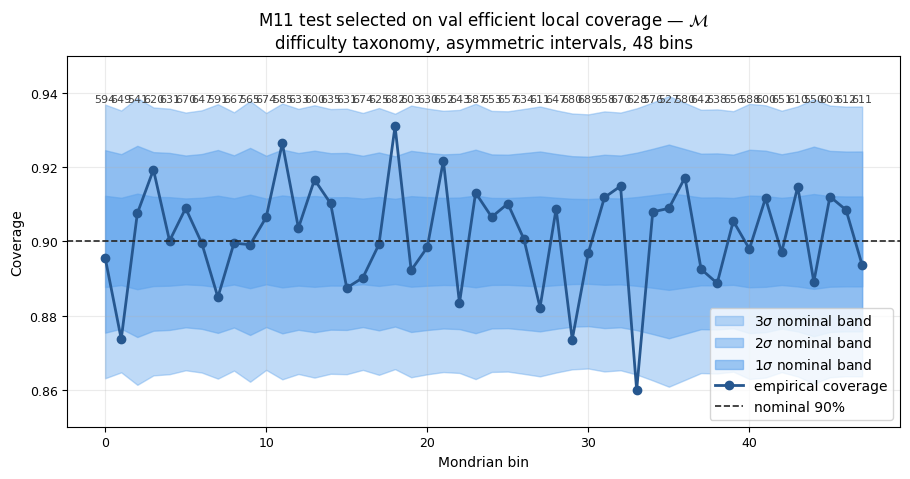

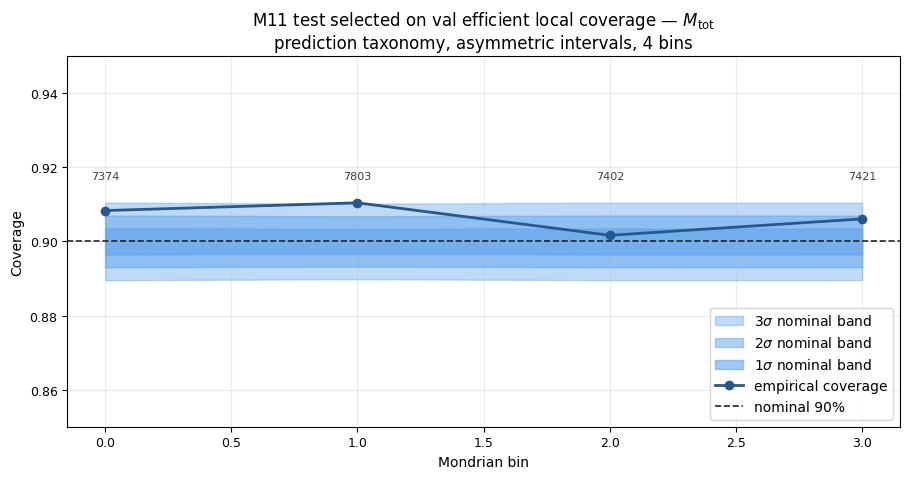

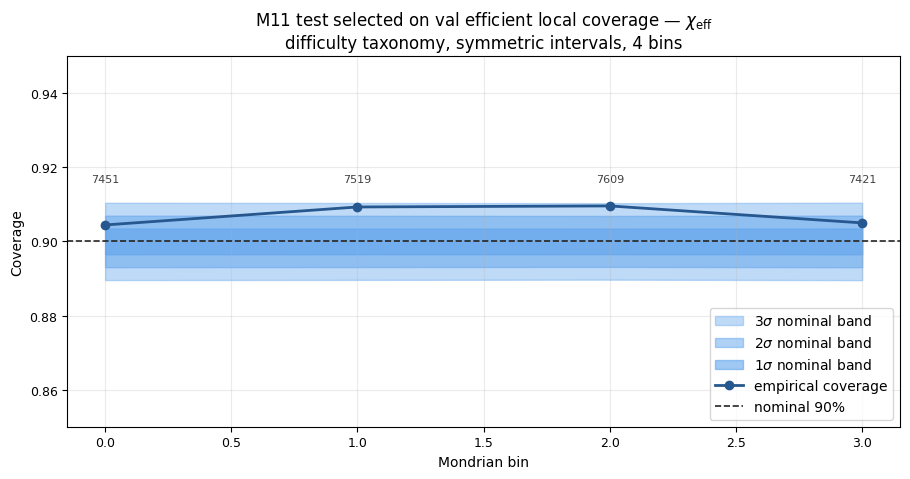

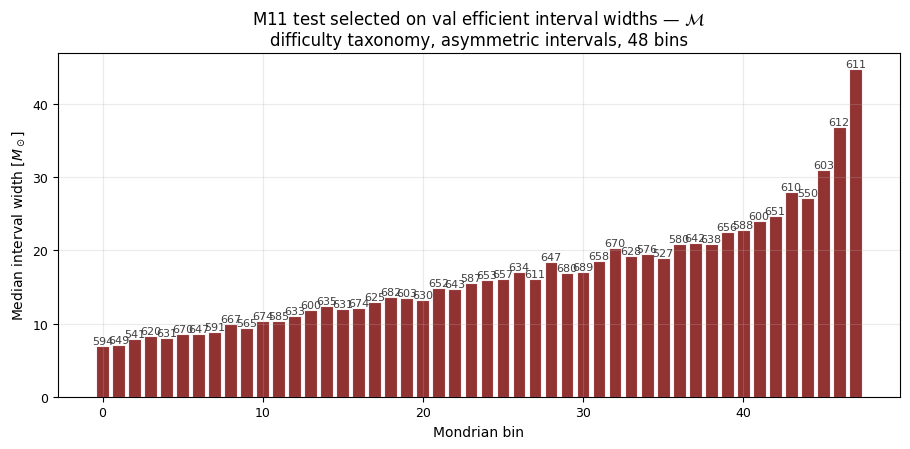

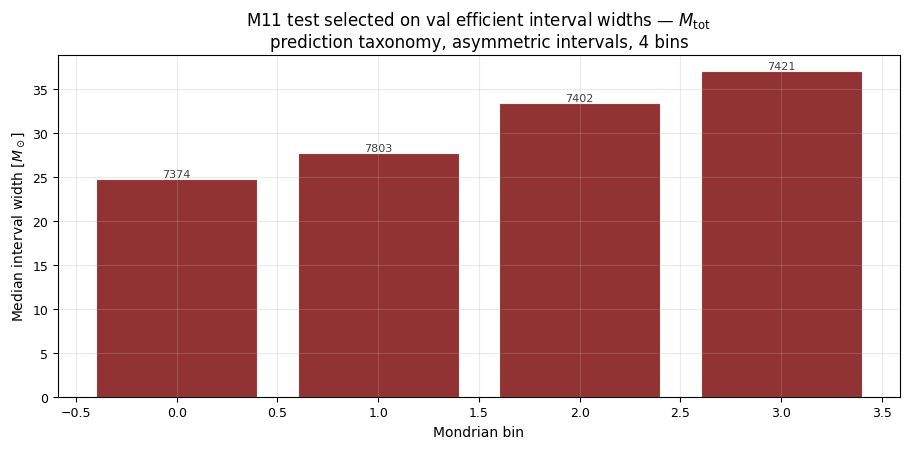

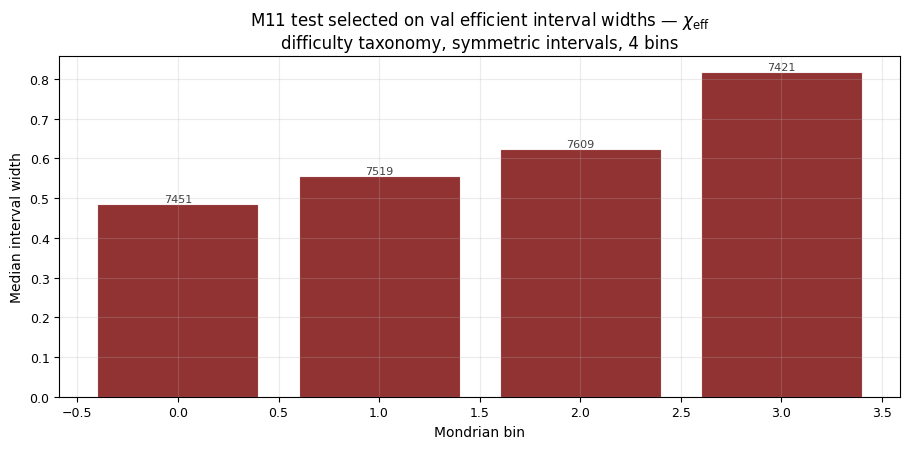

In [18]:
plot_selected_bin_coverage(final_policy="efficient")
plot_selected_bin_widths(final_policy="efficient")

In [19]:
# Counts y métricas VAL para TODO el grid, incluidos bins vacíos.
# Las columnas cal_count y median_width_phys son auxiliares de presentación.
bin_rows = []
for (taxonomy_mode, interval_mode, n_bins), result in all_results.items():
    for j, label in enumerate(label_names):
        for b in range(n_bins):
            mask = result.bin_indices_test[:, j] == b
            width = (result.upper[mask, j] - result.lower[mask, j]) * y_std[j]
            bin_rows.append(dict(
                taxonomy_mode=taxonomy_mode, interval_mode=interval_mode,
                n_bins=n_bins, label=label, bin=b, evaluation_split="val",
                cal_count=int(np.sum(result.bin_indices_cal[:, j] == b)),
                count=int(result.metrics["counts_per_bin"][b, j]),
                coverage=float(result.metrics["coverage_per_bin"][b, j]),
                median_width_phys=float(np.median(width)) if width.size else np.nan,
                low_2sigma=float(result.metrics["bin_tolerance_normal"]["2sigma_low"][b, j]),
                high_2sigma=float(result.metrics["bin_tolerance_normal"]["2sigma_high"][b, j])))
bin_diagnostics_df = pd.DataFrame(bin_rows)
selected_val_bin_diagnostics_df = selection_df[
    ["final_policy", "label", "taxonomy_mode", "interval_mode", "n_bins"]
].merge(bin_diagnostics_df, on=["label", "taxonomy_mode", "interval_mode", "n_bins"],
        validate="many_to_many")
display(selected_val_bin_diagnostics_df)

,final_policy,label,taxonomy_mode,interval_mode,n_bins,bin,evaluation_split,cal_count,count,coverage,median_width_phys,low_2sigma,high_2sigma
0,conservative,chirp_mass,difficulty,asymmetric,16,0,val,1875,2519,0.897181,7.242231,0.888045,0.911955
1,conservative,chirp_mass,difficulty,asymmetric,16,1,val,1875,2567,0.901052,8.264454,0.888158,0.911842
2,conservative,chirp_mass,difficulty,asymmetric,16,2,val,1875,2529,0.901542,9.182444,0.888069,0.911931
3,conservative,chirp_mass,difficulty,asymmetric,16,3,val,1875,2448,0.906046,10.234334,0.887873,0.912127
4,conservative,chirp_mass,difficulty,asymmetric,16,4,val,1875,2506,0.909816,11.694184,0.888014,0.911986
...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,conservative,chi_eff,difficulty,symmetric,8,7,val,3750,4928,0.906453,0.939238,0.891453,0.908547
80,efficient,chi_eff,difficulty,symmetric,4,0,val,7500,9848,0.898152,0.484232,0.893954,0.906046
81,efficient,chi_eff,difficulty,symmetric,4,1,val,7500,10185,0.901915,0.556532,0.894055,0.905945
82,efficient,chi_eff,difficulty,symmetric,4,2,val,7500,10032,0.904107,0.623795,0.894010,0.905990


## 10. Final test systems, misses y width distributions

Cada fila usa métricas **test** del sistema ya elegido en val; no se copian métricas
val a la tabla final. Lower miss = `y < lower`; upper miss = `y > upper`;
imbalance = diferencia absoluta de tasas. Anchos físicos: mediana, q90 y q95.
Las combinaciones `no_strict_candidate` permanecen en `final_test_evaluation_df`
con métricas ausentes; no se evalúa una configuración sustituta.

In [20]:
def summarize_selected_systems():
    rows = []

    for final_policy in ["conservative", "efficient"]:
        for label in label_names:
            label_idx = label_names.index(label)
            row, result = get_selected_result(label, final_policy=final_policy)
            if result is None:
                continue

            widths_phys = (result.upper - result.lower)[:, 0] * y_std[label_idx]
            covered = (
                (result.lower[:, 0] <= y_test[:, label_idx])
                & (y_test[:, label_idx] <= result.upper[:, 0])
            )

            rows.append({
                "final_policy": final_policy,
                "label": label,
                "taxonomy_mode": row["taxonomy_mode"],
                "interval_mode": row["interval_mode"],
                "n_bins": int(row["n_bins"]),
                "coverage": float(covered.mean()),
                "min_count_per_bin": int(row["min_count_per_bin"]),
                "lower_miss_rate": row["lower_miss_rate"],
                "upper_miss_rate": row["upper_miss_rate"],
                "under_bin_fraction_2sigma": row["under_bin_fraction_2sigma"],
                "global_within_2sigma": row["global_within_2sigma"],
                "selection_policy": row["selection_policy"],
                "median_width_phys": float(np.median(widths_phys)),
                "q90_width_phys": float(np.quantile(widths_phys, 0.90)),
                "q95_width_phys": float(np.quantile(widths_phys, 0.95)),
                "min_coverage_per_bin": row["min_coverage_per_bin"],
                "n_bins_under_2sigma": int(row["n_bins_under_2sigma"]),
                "max_undercoverage_gap": row["max_undercoverage_gap"],
                "tail_miss_imbalance": row["global_tail_miss_imbalance"],
            })

    return pd.DataFrame(rows, columns=['final_policy', 'label', 'taxonomy_mode', 'interval_mode', 'n_bins', 'coverage', 'min_count_per_bin', 'lower_miss_rate', 'upper_miss_rate', 'under_bin_fraction_2sigma', 'global_within_2sigma', 'selection_policy', 'median_width_phys', 'q90_width_phys', 'q95_width_phys', 'min_coverage_per_bin', 'n_bins_under_2sigma', 'max_undercoverage_gap', 'tail_miss_imbalance'])


selected_systems_df = summarize_selected_systems()
display(selected_systems_df)

,final_policy,label,taxonomy_mode,interval_mode,n_bins,coverage,min_count_per_bin,lower_miss_rate,upper_miss_rate,under_bin_fraction_2sigma,global_within_2sigma,selection_policy,median_width_phys,q90_width_phys,q95_width_phys,min_coverage_per_bin,n_bins_under_2sigma,max_undercoverage_gap,tail_miss_imbalance
0,conservative,chirp_mass,difficulty,asymmetric,16,0.902500,1731,0.048067,0.049433,0.0000,True,conservative_zero_under_bins_2sigma,15.002292,26.755825,37.546419,0.889061,0,0.010939,0.001367
1,conservative,total_mass,prediction,asymmetric,4,0.906667,7374,0.044333,0.049000,0.0000,False,conservative_zero_under_bins_2sigma,27.696938,37.025800,37.025800,0.901648,0,0.000000,0.004667
2,conservative,chi_eff,difficulty,symmetric,8,0.905233,3654,0.048233,0.046533,0.0000,False,conservative_zero_under_bins_2sigma,0.608739,0.939238,0.939238,0.892733,0,0.007267,0.001700
3,efficient,chirp_mass,difficulty,asymmetric,48,0.901600,527,0.049700,0.048700,0.0625,True,efficient_local_validity_tolerant,15.552326,24.703121,30.971286,0.859873,3,0.040127,0.001000
4,efficient,total_mass,prediction,asymmetric,4,0.906667,7374,0.044333,0.049000,0.0000,False,efficient_local_validity_tolerant,27.696938,37.025800,37.025800,0.901648,0,0.000000,0.004667
5,efficient,chi_eff,difficulty,symmetric,4,0.907100,7421,0.046867,0.046033,0.0000,False,efficient_local_validity_tolerant,0.623795,0.816566,0.816566,0.904442,0,0.000000,0.000833


## 11. M10 comparison — descriptive only

CSV final M10 frente a métricas finales test M11. Datasets/calibradores distintos:
comparación descriptiva, no pareada. **M10 seleccionaba con test; M11 selecciona
con val y evalúa en test.** Ese cambio de protocolo limita la comparabilidad.
No se inventan resultados para labels/políticas sin candidato val estricto.

In [21]:
comparison_df = pd.DataFrame()
if M10_SELECTED_PATH.is_file():
    m10_selected = pd.read_csv(M10_SELECTED_PATH)
    keys = ["final_policy", "label"]
    require(not m10_selected.duplicated(keys).any(), "Claves M10 repetidas")
    require(set(m10_selected["label"]) == set(LABEL_NAMES), "Labels M10 inesperados")
    common = [c for c in selected_systems_df.columns if c in m10_selected.columns and c not in keys]
    comparison_df = m10_selected[keys + common].merge(
        selected_systems_df[keys + common], on=keys, how="outer",
        suffixes=("_M10", "_M11"), validate="one_to_one")
    comparison_df = comparison_df.merge(
        selection_status_df, on=keys, how="outer", validate="one_to_one")
    print("Referencia M10:", M10_SELECTED_PATH)
    display(comparison_df)
else:
    print("Sin CSV M10 disponible; se omite comparación:", M10_SELECTED_PATH)

Referencia M10: /data/vserrano/cbc_pe_data/results/mondrian_M10_final_baseline/selected_systems_summary.csv


,final_policy,label,taxonomy_mode_M10,interval_mode_M10,n_bins_M10,coverage_M10,median_width_phys_M10,q90_width_phys_M10,q95_width_phys_M10,min_coverage_per_bin_M10,...,coverage_M11,median_width_phys_M11,q90_width_phys_M11,q95_width_phys_M11,min_coverage_per_bin_M11,n_bins_under_2sigma_M11,max_undercoverage_gap_M11,tail_miss_imbalance_M11,selection_status,n_strict_candidates
0,conservative,chi_eff,prediction,symmetric,8,0.900267,0.582661,0.687546,0.687546,0.894415,...,0.905233,0.608739,0.939238,0.939238,0.892733,0,0.007267,0.001700,selected,12
1,conservative,chirp_mass,difficulty,asymmetric,4,0.900533,11.775588,22.665657,22.665657,0.898476,...,0.902500,15.002292,26.755825,37.546419,0.889061,0,0.010939,0.001367,selected,3
2,conservative,total_mass,prediction,asymmetric,6,0.899533,26.199136,35.239614,35.239614,0.893254,...,0.906667,27.696938,37.025800,37.025800,0.901648,0,0.000000,0.004667,selected,2
3,efficient,chi_eff,difficulty,asymmetric,12,0.899033,0.543044,0.691346,0.907825,0.884677,...,0.907100,0.623795,0.816566,0.816566,0.904442,0,0.000000,0.000833,selected,17
4,efficient,chirp_mass,difficulty,symmetric,4,0.901167,11.731975,22.774741,22.774741,0.898414,...,0.901600,15.552326,24.703121,30.971286,0.859873,3,0.040127,0.001000,selected,12
5,efficient,total_mass,difficulty,symmetric,4,0.900567,25.844899,38.893264,38.893264,0.898056,...,0.906667,27.696938,37.025800,37.025800,0.901648,0,0.000000,0.004667,selected,3


## 12. Metadata ligera y conditional diagnostics

Los tres targets verdaderos proceden del NPZ desestandarizado y conservan su orden.
Se inspeccionó el HDF5 M11: SNR está en `final_network_snr`, no en `snr/network`.
Es SNR óptimo final en 30–512 Hz; no se sustituye por target ni por SNR observado.
Sólo se lee ese campo 1D en índices test, nunca `X`. No se equipara
`full_network_duration` con `placement/signal_network_duration` de M10.
Sin HDF5, los diagnósticos de los tres targets siguen disponibles.

Se reutiliza `binned_conditional_metrics` de M10, celda 25: ocho bins cuantiles test,
bordes únicos, intervalos [left,right) y último cerrado, omitiendo vacíos.
Son diagnósticos descriptivos; no modifican calibradores ni selección.

In [22]:
import h5py

def read_hdf5_dataset_preserve_order(h5_file, dataset_key, indices, dtype=None):
    indices = np.asarray(indices, dtype=np.int64)
    order = np.argsort(indices, kind="stable")
    sorted_indices = indices[order]

    values_sorted = np.asarray(h5_file[dataset_key][sorted_indices], dtype=dtype)

    inverse_order = np.empty_like(order)
    inverse_order[order] = np.arange(len(order))

    return values_sorted[inverse_order]



test_meta_df = pd.DataFrame({"hdf5_index": idx_test,
    **{label: y_test_phys[:, j] for j, label in enumerate(label_names)}})
if DATASET_PATH.is_file():
    with h5py.File(DATASET_PATH, "r") as h:
        require(h.attrs.get("experiment_id") == DATASET_ID, "HDF5 de otro dataset")
        require(h.attrs.get("labels") == ",".join(LABEL_NAMES), "Labels HDF5 incorrectos")
        print("Campos reales HDF5:", list(h.keys()))
        if "final_network_snr" in h:
            require(h["final_network_snr"].shape == (500000,), "Shape SNR incorrecta")
            require(h.attrs.get("snr_low_frequency_cutoff") == 30.0 and
                    h.attrs.get("snr_high_frequency_cutoff") == 512.0, "Banda SNR inesperada")
            snr = read_hdf5_dataset_preserve_order(h, "final_network_snr", idx_test)
            require(np.isfinite(snr).all(), "SNR no finito")
            test_meta_df["final_network_snr"] = snr
        else:
            print("Sin final_network_snr; diagnóstico SNR omitido")
else:
    print("HDF5 no disponible; diagnóstico SNR omitido:", DATASET_PATH)
display(test_meta_df.head())

Campos reales HDF5: ['X', 'actual_geocentric_time', 'block_id', 'center_gps', 'chi_eff', 'chirp_mass', 'config_sha256', 'crop_index', 'dec', 'distance_mpc', 'experiment_id', 'file_group_id', 'final_distance', 'final_network_snr', 'full_network_duration', 'gaussian_seed', 'gaussian_seed_H1', 'gaussian_seed_L1', 'gaussian_seed_V1', 'geocentric_time', 'geocentric_time_policy', 'inclination', 'is_truncated', 'manifest_index', 'mass_1', 'mass_2', 'noise_crop_id', 'noise_region_end', 'noise_region_start', 'placement_offset_s', 'placement_seed', 'polarization_angle', 'processing_end', 'processing_start', 'psd_end', 'psd_start', 'ra', 'reference_distance', 'reference_distance_mpc', 'reference_geocentric_time', 'reference_network_snr', 'required_final_duration', 'snr_H1', 'snr_L1', 'snr_V1', 'source_id', 'source_index', 'spin_1z', 'spin_2z', 'split', 'status', 'target_network_snr', 'total_mass', 'y']


,hdf5_index,chirp_mass,total_mass,chi_eff,final_network_snr
0,470000,29.933697,82.275245,-0.568804,24.709981
1,470001,58.853843,135.907241,-0.155438,19.721921
2,470002,29.852245,73.638322,0.325388,20.961022
3,470003,27.942839,82.805901,-0.114439,11.092364
4,470004,29.161567,69.554947,0.915412,14.506400


In [23]:
def binned_conditional_metrics(values, covered, widths_phys, n_bins=8):
    values = np.asarray(values)
    covered = np.asarray(covered, dtype=bool)
    widths_phys = np.asarray(widths_phys)

    edges = np.quantile(values, np.linspace(0, 1, n_bins + 1))
    edges = np.unique(edges)

    rows = []
    for i, (left, right) in enumerate(zip(edges[:-1], edges[1:])):
        if i == len(edges) - 2:
            mask = (values >= left) & (values <= right)
        else:
            mask = (values >= left) & (values < right)

        if mask.sum() == 0:
            continue

        rows.append({
            "bin": i,
            "left": float(left),
            "right": float(right),
            "center": float(0.5 * (left + right)),
            "count": int(mask.sum()),
            "coverage": float(covered[mask].mean()),
            "median_width_phys": float(np.median(widths_phys[mask])),
            "mean_width_phys": float(np.mean(widths_phys[mask])),
        })

    return pd.DataFrame(rows)


conditional_rows = []
conditional_tables = {}

conditioning_specs = [
    ("final_network_snr", "Final optimal network SNR (30–512 Hz)"),
    ("chirp_mass", field_tex("chirp_mass")),
    ("total_mass", field_tex("total_mass")),
    ("chi_eff", field_tex("chi_eff")),
]

for final_policy in ["conservative", "efficient"]:
    for label in label_names:
        label_idx = label_names.index(label)
        row, result = get_selected_result(label, final_policy=final_policy)
        if result is None:
            continue

        covered = (
            (result.lower[:, 0] <= y_test[:, label_idx])
            & (y_test[:, label_idx] <= result.upper[:, 0])
        )

        widths_phys = (result.upper - result.lower)[:, 0] * y_std[label_idx]

        for field, field_label in conditioning_specs:
            if field not in test_meta_df.columns:
                continue

            table = binned_conditional_metrics(
                values=test_meta_df[field].values,
                covered=covered,
                widths_phys=widths_phys,
                n_bins=8,
            )

            table["final_policy"] = final_policy
            table["label"] = label
            table["label_tex"] = label_tex(label)
            table["conditioning_field"] = field
            table["conditioning_label"] = field_label

            conditional_tables[(final_policy, label, field)] = table
            conditional_rows.append(table)

conditional_metrics_df = (pd.concat(conditional_rows, ignore_index=True) if conditional_rows
    else pd.DataFrame(columns=["bin", "left", "right", "center", "count", "coverage",
        "median_width_phys", "mean_width_phys", "final_policy", "label", "label_tex",
        "conditioning_field", "conditioning_label"]))
display(conditional_metrics_df.head(20))

,bin,left,right,center,count,coverage,median_width_phys,mean_width_phys,final_policy,label,label_tex,conditioning_field,conditioning_label
0,0,10.001520,11.848581,10.925050,3750,0.826667,18.951712,19.712388,conservative,chirp_mass,$\mathcal{M}$,final_network_snr,Final optimal network SNR (30–512 Hz)
1,1,11.848581,13.738185,12.793383,3750,0.863467,17.083339,18.464153,conservative,chirp_mass,$\mathcal{M}$,final_network_snr,Final optimal network SNR (30–512 Hz)
2,2,13.738185,15.620562,14.679373,3750,0.885867,16.185356,17.226876,conservative,chirp_mass,$\mathcal{M}$,final_network_snr,Final optimal network SNR (30–512 Hz)
3,3,15.620562,17.470887,16.545724,3750,0.896267,15.002292,16.557912,conservative,chirp_mass,$\mathcal{M}$,final_network_snr,Final optimal network SNR (30–512 Hz)
4,4,17.470887,19.354129,18.412508,3750,0.915733,15.002292,16.041033,conservative,chirp_mass,$\mathcal{M}$,final_network_snr,Final optimal network SNR (30–512 Hz)
5,5,19.354129,21.225647,20.289888,3750,0.940800,15.002292,15.549935,conservative,chirp_mass,$\mathcal{M}$,final_network_snr,Final optimal network SNR (30–512 Hz)
6,6,21.225647,23.109146,22.167397,3750,0.940267,13.419498,15.225504,conservative,chirp_mass,$\mathcal{M}$,final_network_snr,Final optimal network SNR (30–512 Hz)
7,7,23.109146,24.999639,24.054392,3750,0.950933,13.419498,14.740722,conservative,chirp_mass,$\mathcal{M}$,final_network_snr,Final optimal network SNR (30–512 Hz)
8,0,4.498729,17.655747,11.077238,3750,0.951467,10.234334,11.489685,conservative,chirp_mass,$\mathcal{M}$,chirp_mass,true $\mathcal{M}$ [$M_\odot$]
9,1,17.655747,23.822800,20.739273,3750,0.923733,10.234334,12.725031,conservative,chirp_mass,$\mathcal{M}$,chirp_mass,true $\mathcal{M}$ [$M_\odot$]


In [24]:
# ============================================================
# 14. Academic-style Mondrian figures (clean presentation style)
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MOND_FIG_DIR = FIGURES_DIR
MOND_FIG_DIR.mkdir(parents=True, exist_ok=True)
print("Saving Mondrian figures to:", MOND_FIG_DIR)

# ------------------------------------------------------------
# Presentation-style palette: blue/grey academic + soft accents
# ------------------------------------------------------------
MOND_COLORS = {
    "bg": "#F5F7FA",
    "box": "#EAF1F7",
    "text": "#1F2D3A",
    "title": "#243B53",
    "muted": "#526D82",
    "grid": "#D7DEE8",

    "coverage": "#6F91B6",
    "coverage_dark": "#243B53",
    "width": "#A56C6C",
    "width_dark": "#7B4C4C",

    "nominal": "#243B53",
    "band1": "#D9E8F5",
    "band2": "#BDD5EA",
    "band3": "#A7C3DF",

    "global": "#C3CDD9",
    "global_edge": "#738496",

    "conservative": "#6F91B6",
    "efficient": "#9CBFA7",

    "prediction": "#6F91B6",
    "difficulty": "#B4A974",

    "symmetric": "#7FA7A6",
    "asymmetric": "#D59B8A",

    "highlight": "#D8A6A6",
    "warning": "#D8A6A6",
}

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.edgecolor": MOND_COLORS["grid"],
    "axes.labelcolor": MOND_COLORS["text"],
    "xtick.color": MOND_COLORS["text"],
    "ytick.color": MOND_COLORS["text"],
    "text.color": MOND_COLORS["text"],
    "axes.titlecolor": MOND_COLORS["title"],
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "font.size": 12,
    "legend.fontsize": 10,
    "axes.grid": True,
    "grid.color": MOND_COLORS["grid"],
    "grid.alpha": 0.55,
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def style_axis_clean(ax):
    ax.grid(True, alpha=0.55, linewidth=0.8, color=MOND_COLORS["grid"])
    ax.tick_params(axis="both", labelsize=10)
    return ax

def savefig_clean(fig, name):
    png_path = MOND_FIG_DIR / f"{name}.png"
    pdf_path = MOND_FIG_DIR / f"{name}.pdf"
    fig.savefig(png_path, dpi=250, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    print("Saved:", png_path.name, "and", pdf_path.name)

def selected_widths_phys(result, label_idx):
    return (result.upper - result.lower)[:, 0] * y_std[label_idx]

def selected_covered_mask(result, label_idx):
    return (
        (result.lower[:, 0] <= y_test[:, label_idx]) &
        (y_test[:, label_idx] <= result.upper[:, 0])
    )

def config_text(row):
    return f"{row['taxonomy_mode']} | {row['interval_mode']} | {int(row['n_bins'])} bins"

def short_config_text(row):
    return f"{row['taxonomy_mode'][:4]} / {row['interval_mode'][:5]} / {int(row['n_bins'])}"

Saving Mondrian figures to: /data/vserrano/cbc_pe_data/results/M11_final_G1_500k/M11_12_final_mondrian_evaluation/figures_cal_val_test


In [25]:
# ============================================================
# 19. Conditional diagnostics in a cleaner multi-panel layout
#     Coverage + width, adaptive axes, no misleading width shading
# ============================================================

def _adaptive_ylim(values, extra_values=None, min_range=None, margin_fraction=0.16, lower_floor=None, upper_cap=None):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if extra_values is not None:
        extra_values = np.asarray(extra_values, dtype=float)
        extra_values = extra_values[np.isfinite(extra_values)]
        values = np.concatenate([values, extra_values])

    if values.size == 0:
        return None

    y_min = float(np.nanmin(values))
    y_max = float(np.nanmax(values))
    y_range = y_max - y_min

    if min_range is not None and y_range < min_range:
        center = 0.5 * (y_min + y_max)
        y_min = center - 0.5 * min_range
        y_max = center + 0.5 * min_range
        y_range = min_range

    if y_range <= 0:
        y_range = max(abs(y_max), 1.0)

    margin = margin_fraction * y_range
    lower = y_min - margin
    upper = y_max + margin

    if lower_floor is not None:
        lower = max(lower_floor, lower)
    if upper_cap is not None:
        upper = min(upper_cap, upper)

    return lower, upper


def plot_conditional_grid(field="network_snr", final_policy="conservative", save=True):
    if not any((final_policy, label, field) in conditional_tables for label in label_names):
        print(f"Sin sistemas seleccionados para {final_policy} / {field}; plot omitido")
        return
    fig, axes = plt.subplots(
        2,
        len(label_names),
        figsize=(5.0 * len(label_names), 7.0),
        sharex="col",
        sharey=False,
        constrained_layout=True,
    )

    if len(label_names) == 1:
        axes = np.asarray(axes).reshape(2, 1)

    for j, label in enumerate(label_names):
        ax_cov = axes[0, j]
        ax_wid = axes[1, j]

        key = (final_policy, label, field)
        if key not in conditional_tables:
            ax_cov.set_visible(False)
            ax_wid.set_visible(False)
            continue

        table = conditional_tables[key].copy()

        x = table["center"].values
        cov = table["coverage"].values
        wid = table["median_width_phys"].values
        cnt = table["count"].values

        # Approximate nominal fluctuation bands around target coverage.
        sigma = np.sqrt(CONFIDENCE_LEVEL * (1.0 - CONFIDENCE_LEVEL) / cnt)
        low_1s = CONFIDENCE_LEVEL - sigma
        high_1s = CONFIDENCE_LEVEL + sigma
        low_2s = CONFIDENCE_LEVEL - 2.0 * sigma
        high_2s = CONFIDENCE_LEVEL + 2.0 * sigma

        # -----------------------------
        # Coverage panel
        # -----------------------------
        ax_cov.fill_between(
            x,
            low_2s,
            high_2s,
            color=MOND_COLORS["band2"],
            alpha=0.35,
            label=r"$2\sigma$ nominal band",
        )

        ax_cov.fill_between(
            x,
            low_1s,
            high_1s,
            color=MOND_COLORS["band2"],
            alpha=0.75,
            label=r"$1\sigma$ nominal band",
        )

        cov_line, = ax_cov.plot(
            x,
            cov,
            marker="o",
            markersize=5,
            linewidth=2.0,
            color=MOND_COLORS["coverage_dark"],
            label="Empirical coverage",
        )

        nominal_line = ax_cov.axhline(
            CONFIDENCE_LEVEL,
            linestyle="--",
            linewidth=1.25,
            color=MOND_COLORS["nominal"],
            label=f"Nominal {int(CONFIDENCE_LEVEL * 100)}%",
        )

        ax_cov.set_title(f"{label_tex(label)}", pad=10)

        if j == 0:
            ax_cov.set_ylabel("Coverage")
        else:
            ax_cov.set_ylabel("")

        cov_ylim = _adaptive_ylim(
            cov,
            extra_values=np.concatenate([
                low_2s,
                high_2s,
                np.array([CONFIDENCE_LEVEL]),
            ]),
            min_range=0.055,
            margin_fraction=0.14,
            lower_floor=0.0,
            upper_cap=1.0,
        )
        ax_cov.set_ylim(*cov_ylim)

        style_axis_clean(ax_cov)

        # -----------------------------
        # Width panel
        # -----------------------------
        wid_line, = ax_wid.plot(
            x,
            wid,
            marker="s",
            markersize=5,
            linewidth=2.0,
            color=MOND_COLORS["width_dark"],
            label="Median interval width",
        )

        # No fill_between: width shading has no statistical meaning here.
        # Keep the plot as a line/marker diagnostic.

        unit = label_unit(label)
        ylabel = f"Median width [{unit}]" if unit else "Median width"

        if j == 0:
            ax_wid.set_ylabel(ylabel)
        else:
            ax_wid.set_ylabel("")

        ax_wid.set_xlabel(table["conditioning_label"].iloc[0])

        wid_ylim = _adaptive_ylim(
            wid,
            min_range=None,
            margin_fraction=0.18,
            lower_floor=None,
            upper_cap=None,
        )
        ax_wid.set_ylim(*wid_ylim)

        style_axis_clean(ax_wid)

    # Shared legend, compact.
    handles = [cov_line, nominal_line]
    labels = [
        "Empirical coverage",
        f"Nominal {int(CONFIDENCE_LEVEL * 100)}%",
    ]

    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=2,
        frameon=False,
        bbox_to_anchor=(0.5, 1.035),
        fontsize=10,
    )

    fig.suptitle(
        f"Selected {final_policy} system: conditional coverage and width vs {field_tex(field)}",
        fontsize=17,
        color=MOND_COLORS["title"],
        y=1.085,
    )

    if save:
        savefig_clean(fig, f"conditional_{final_policy}_{field}")

    plt.show()
    plt.close(fig)

Saved: conditional_conservative_final_network_snr.png and conditional_conservative_final_network_snr.pdf


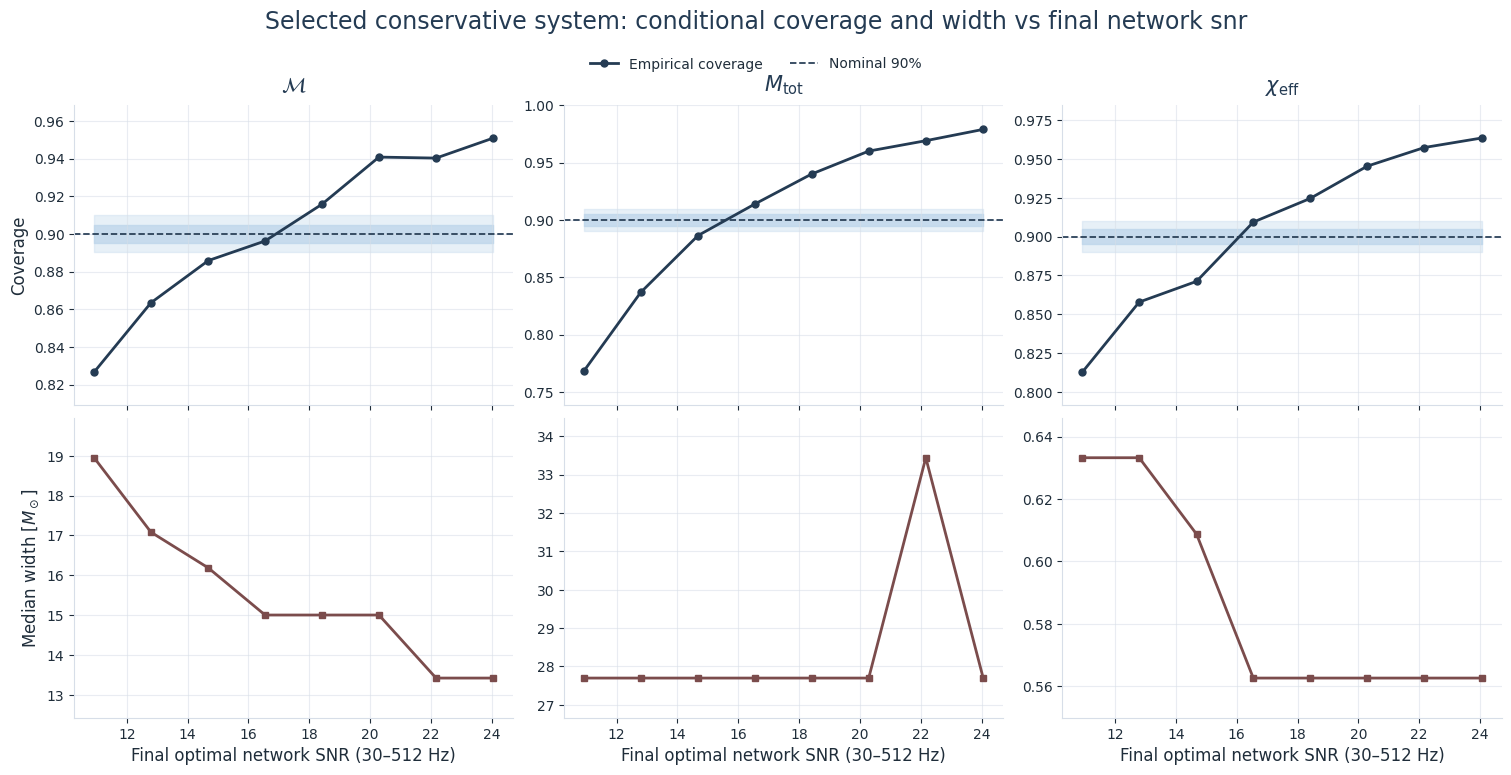

Saved: conditional_efficient_final_network_snr.png and conditional_efficient_final_network_snr.pdf


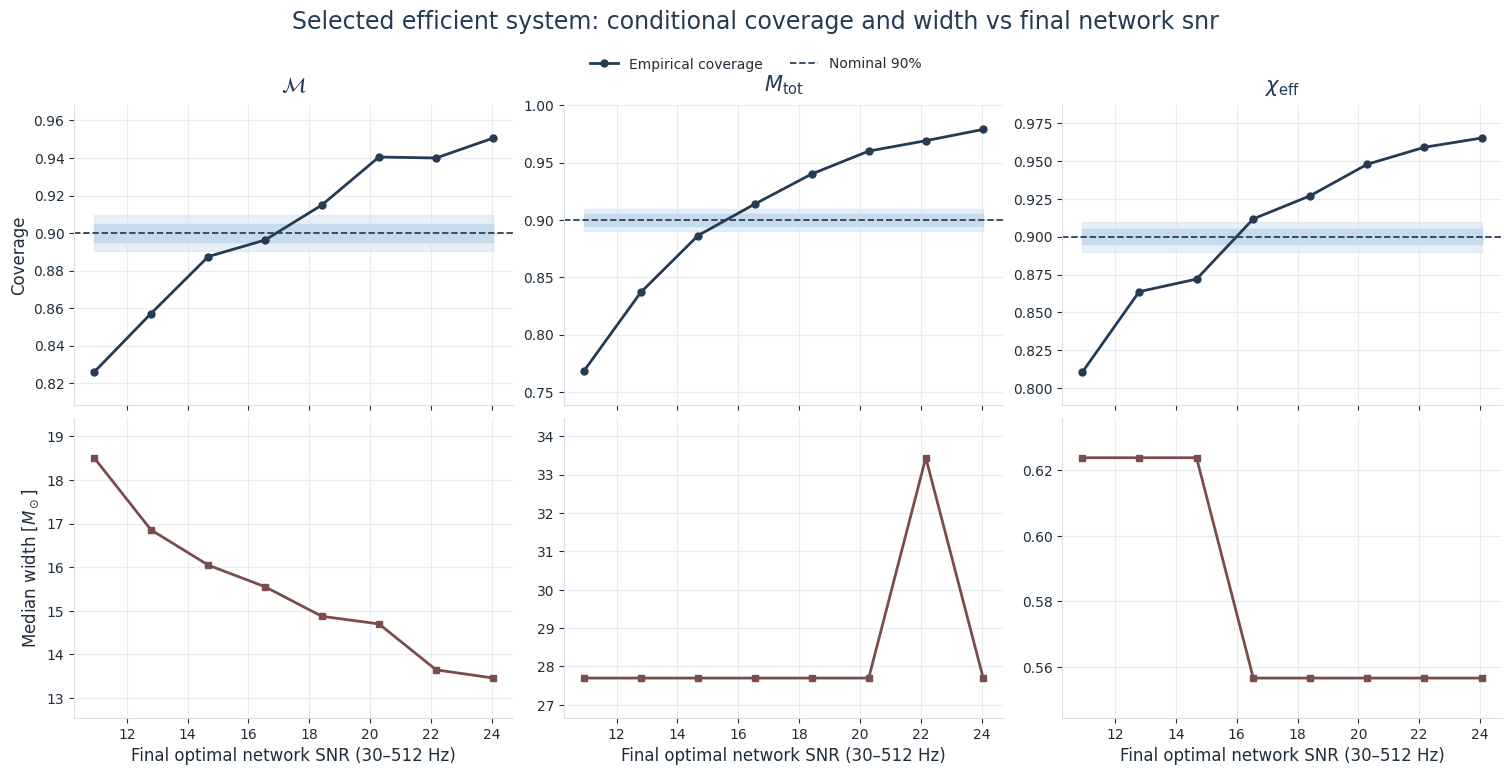

Saved: conditional_conservative_chirp_mass.png and conditional_conservative_chirp_mass.pdf


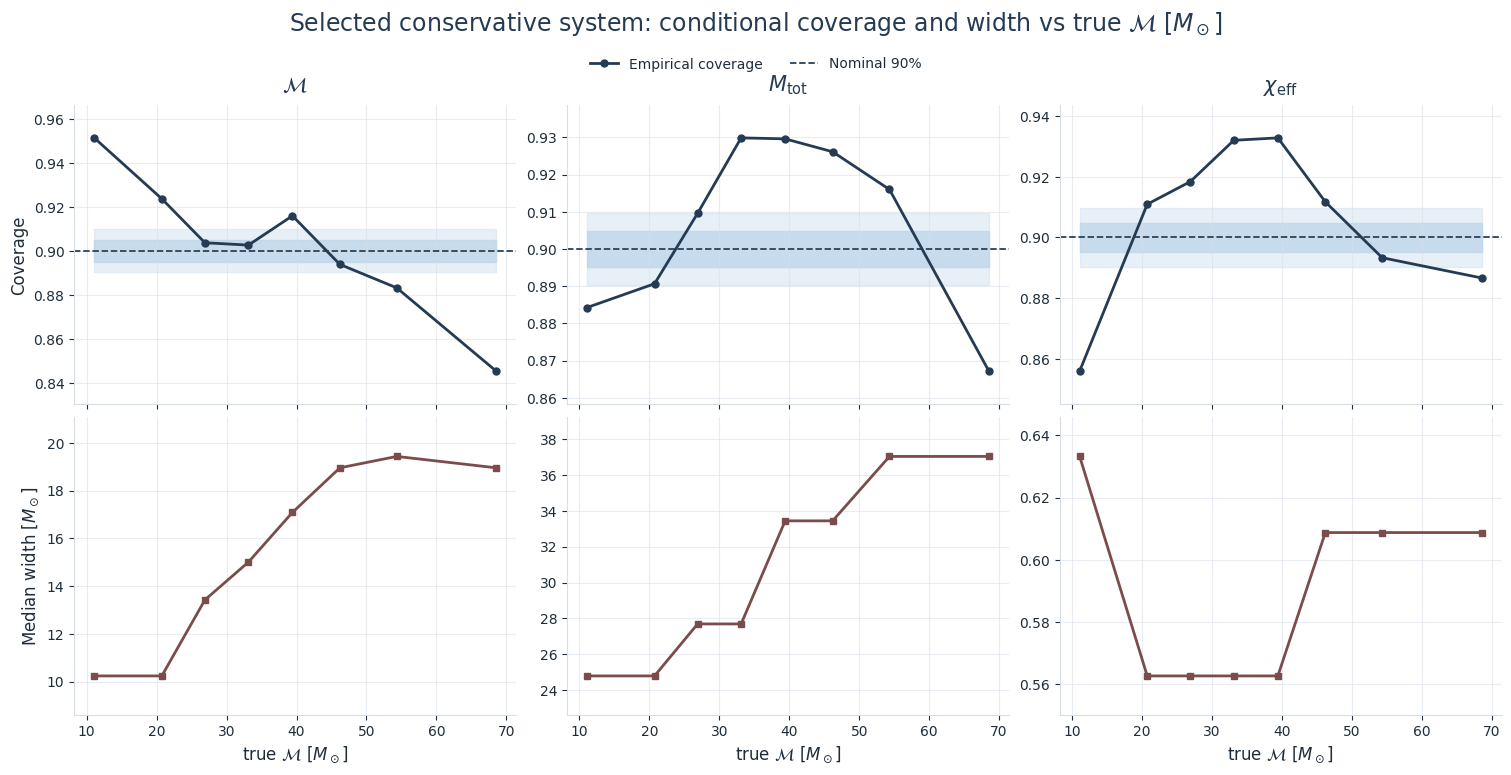

Saved: conditional_efficient_chirp_mass.png and conditional_efficient_chirp_mass.pdf


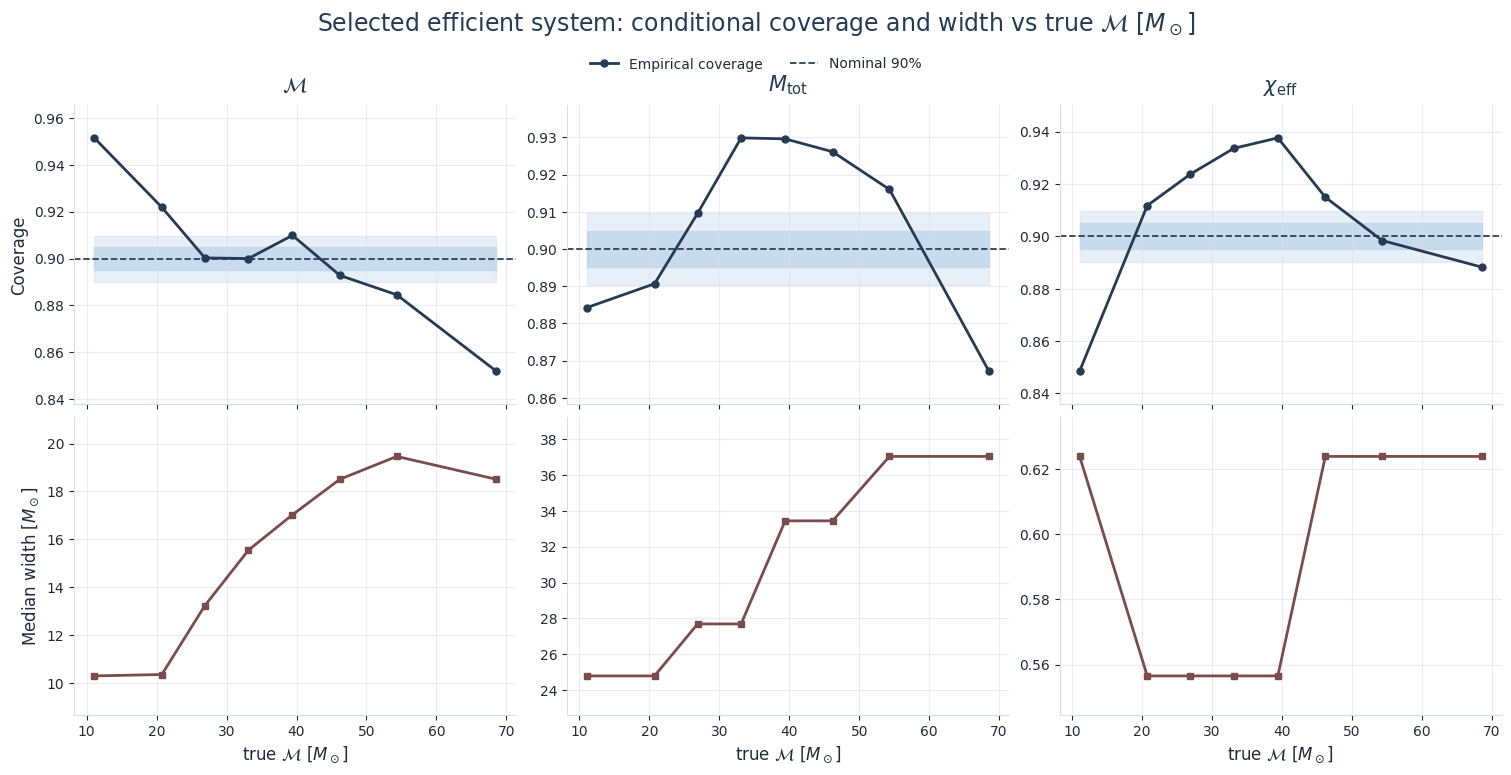

Saved: conditional_conservative_total_mass.png and conditional_conservative_total_mass.pdf


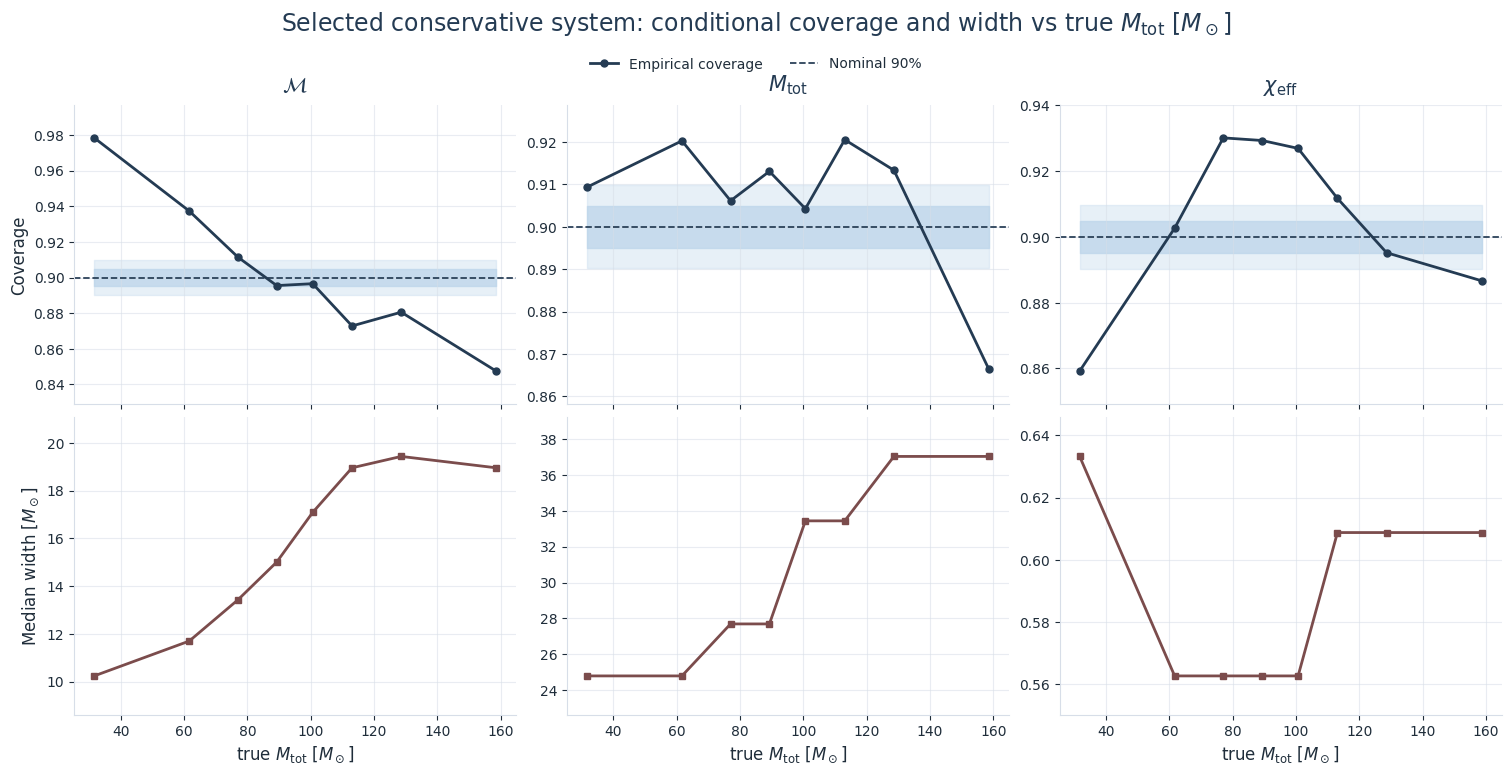

Saved: conditional_efficient_total_mass.png and conditional_efficient_total_mass.pdf


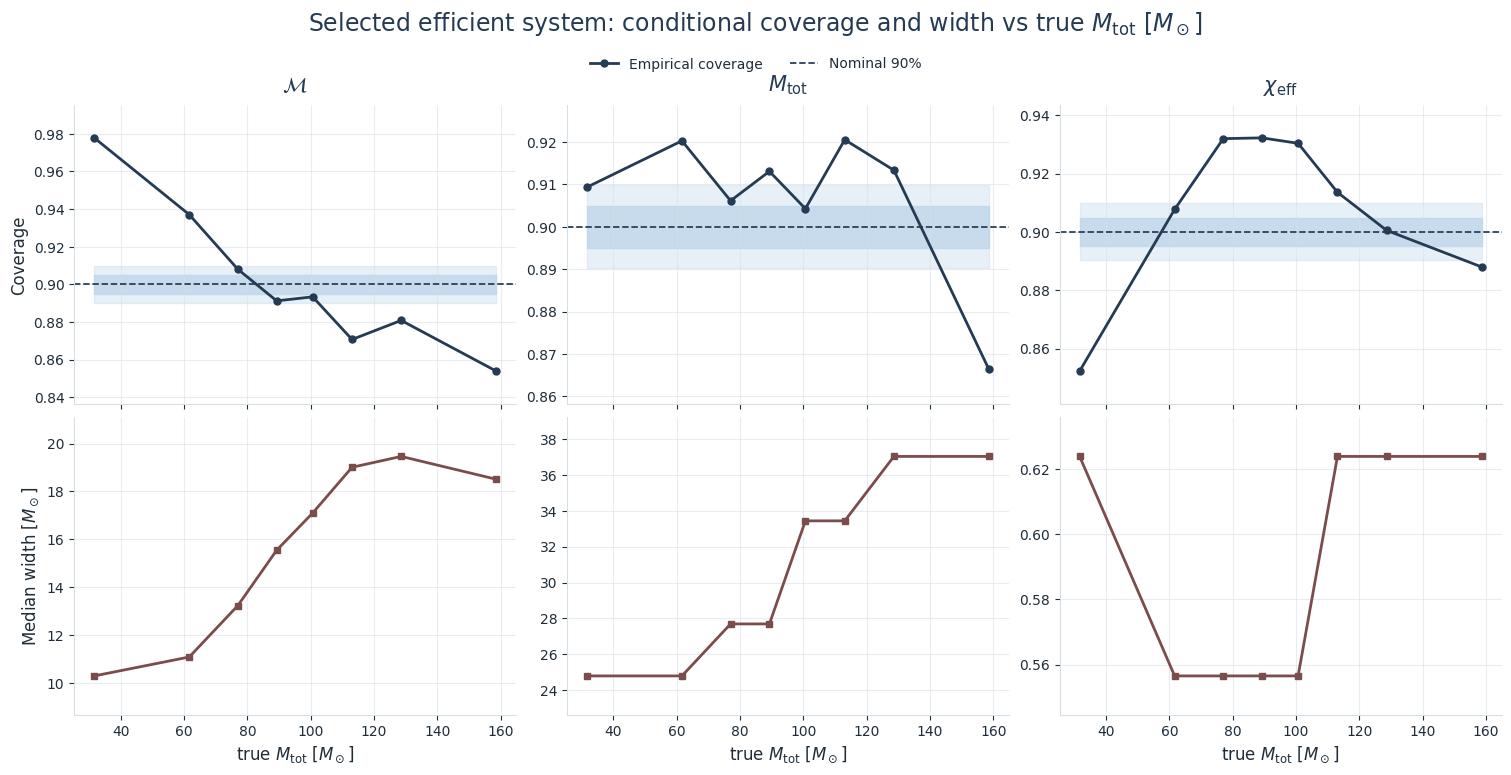

Saved: conditional_conservative_chi_eff.png and conditional_conservative_chi_eff.pdf


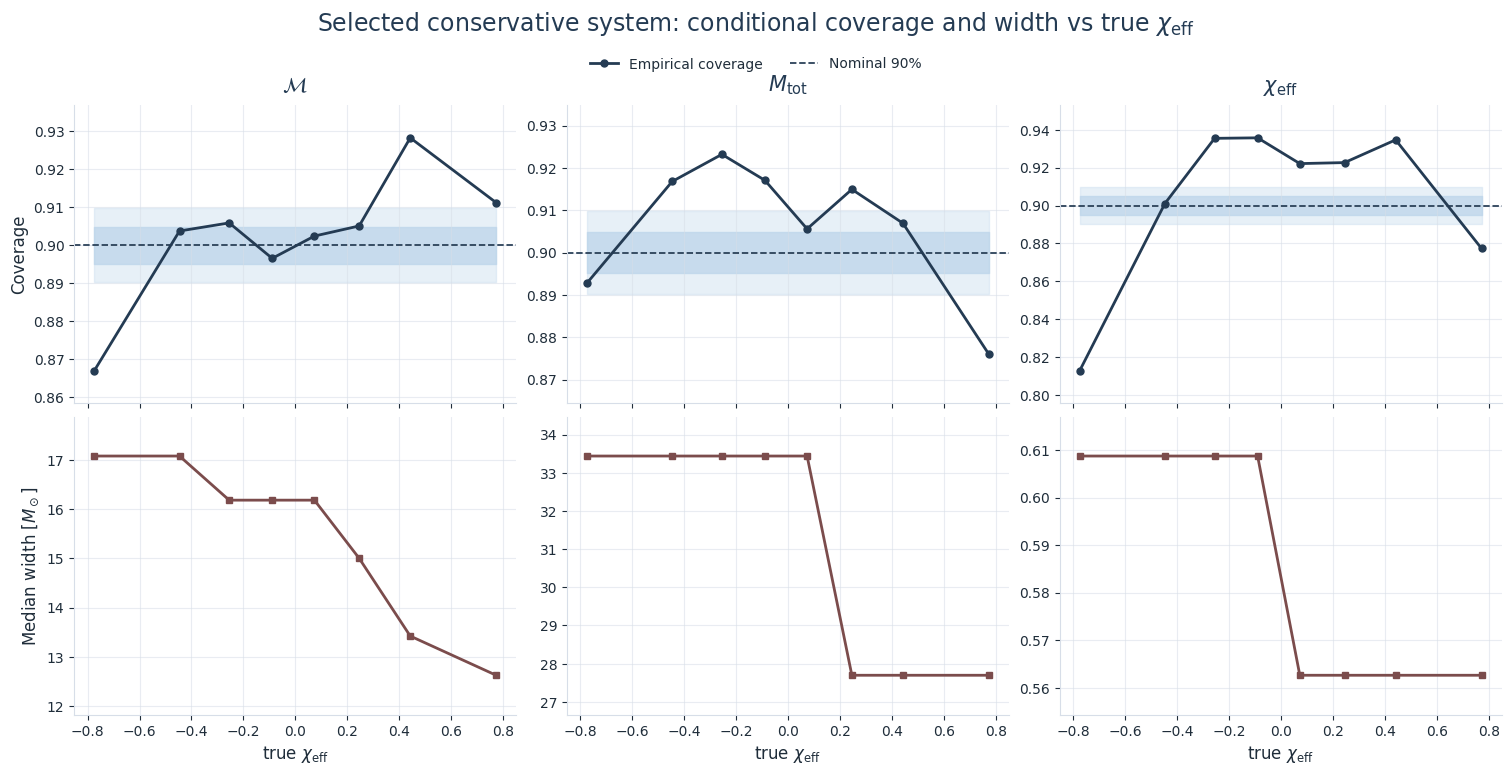

Saved: conditional_efficient_chi_eff.png and conditional_efficient_chi_eff.pdf


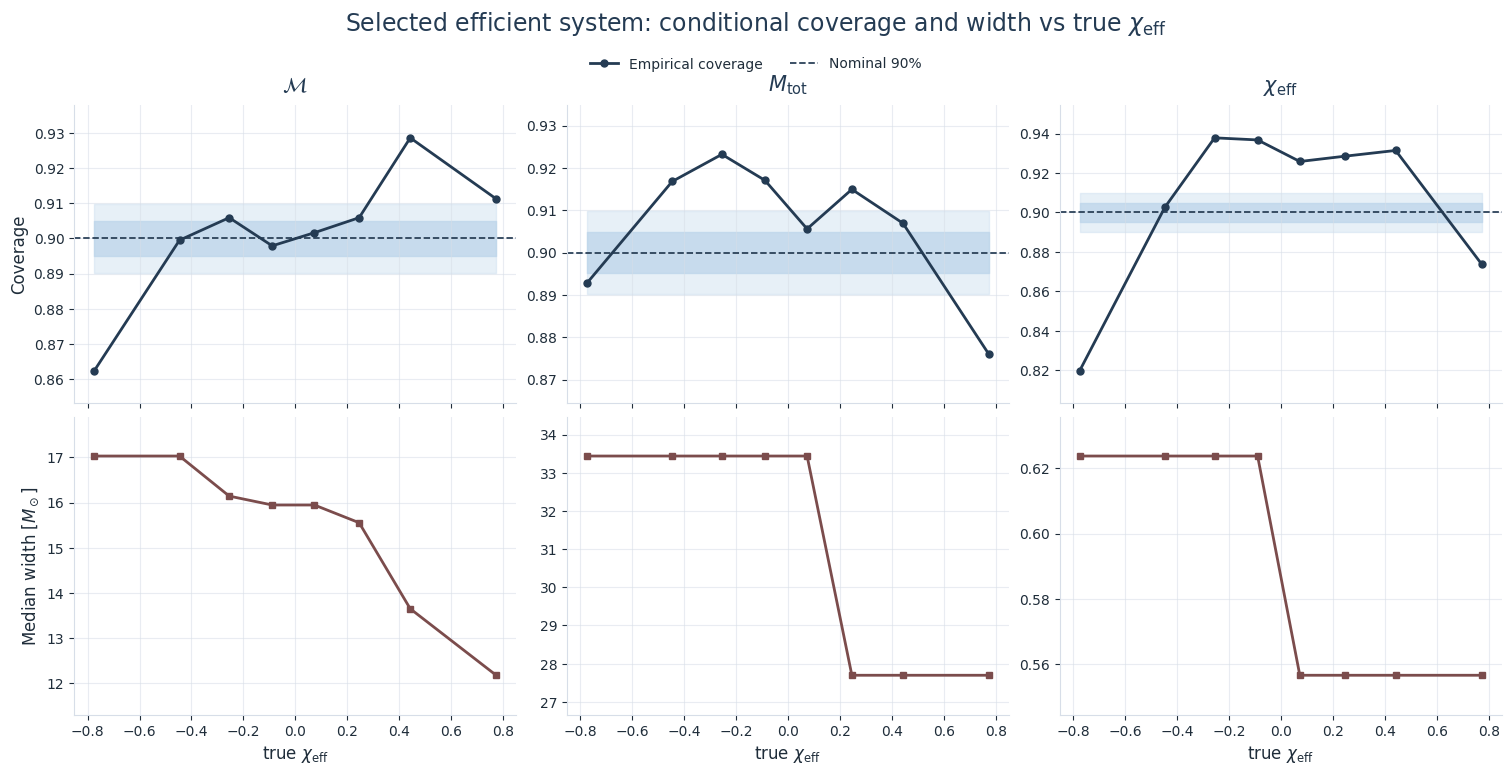

In [26]:
for field, _ in conditioning_specs:
    if field in test_meta_df.columns:
        for policy in ["conservative", "efficient"]:
            plot_conditional_grid(field=field, final_policy=policy)

## 13. Save artifacts — split roles explicit

Tres outputs separados en `results/M11_final_G1_500k/`:
- `mondrian_m11_val_grid_summary.csv`: todas las métricas val del grid.
- `mondrian_m11_selected_from_val.csv`: decisiones y métricas val, incluidos estados sin candidato.
- `mondrian_m11_final_test_evaluation.csv`: métricas test únicamente de sistemas seleccionados;
  estados sin candidato con métricas vacías.

Además se guardan diagnósticos val, tablas condicionales test, comparación, reporte y
provenance. No se serializan nuevos calibradores ni se sobrescriben artefactos M10.
Las figuras cal→val→test usan un subdirectorio propio para distinguirlas de ejecuciones anteriores.

In [27]:
def format_selected_systems_for_report(selected_systems_df):
    """
    Produce a compact text summary from selected_systems_df.
    Execute after selected_systems_df has been computed.
    """
    lines = []

    for policy in ["conservative", "efficient"]:
        sub = selected_systems_df[selected_systems_df["final_policy"] == policy]

        lines.append(f"\n{policy.upper()} SELECTED SYSTEMS")
        lines.append("-" * 80)

        missing = selection_status_df[
            (selection_status_df["final_policy"] == policy)
            & (selection_status_df["selection_status"] == "no_strict_candidate")]
        for label in missing["label"]:
            lines.append(f"{label}: no_strict_candidate (sin fallback)")

        for _, row in sub.iterrows():
            label = row["label"]
            unit = label_unit(label)

            width_unit = f" {unit}" if unit else ""

            lines.append(
                f"{label_tex(label)}: "
                f"{row['taxonomy_mode']} / {row['interval_mode']} / "
                f"{int(row['n_bins'])} bins | "
                f"coverage={row['coverage']:.4f}, "
                f"median width={row['median_width_phys']:.4g}{width_unit}, "
                f"q95 width={row['q95_width_phys']:.4g}{width_unit}, "
                f"min bin coverage={row['min_coverage_per_bin']:.4f}, "
                f"under-2σ bins={int(row['n_bins_under_2sigma'])}"
            )

    return "\n".join(lines)


print(format_selected_systems_for_report(selected_systems_df))


CONSERVATIVE SELECTED SYSTEMS
--------------------------------------------------------------------------------
$\mathcal{M}$: difficulty / asymmetric / 16 bins | coverage=0.9025, median width=15 $M_\odot$, q95 width=37.55 $M_\odot$, min bin coverage=0.8891, under-2σ bins=0
$M_{\mathrm{tot}}$: prediction / asymmetric / 4 bins | coverage=0.9067, median width=27.7 $M_\odot$, q95 width=37.03 $M_\odot$, min bin coverage=0.9016, under-2σ bins=0
$\chi_{\mathrm{eff}}$: difficulty / symmetric / 8 bins | coverage=0.9052, median width=0.6087, q95 width=0.9392, min bin coverage=0.8927, under-2σ bins=0

EFFICIENT SELECTED SYSTEMS
--------------------------------------------------------------------------------
$\mathcal{M}$: difficulty / asymmetric / 48 bins | coverage=0.9016, median width=15.55 $M_\odot$, q95 width=30.97 $M_\odot$, min bin coverage=0.8599, under-2σ bins=3
$M_{\mathrm{tot}}$: prediction / asymmetric / 4 bins | coverage=0.9067, median width=27.7 $M_\odot$, q95 width=37.03 $M_\odot$,

In [28]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
tables = {
    "mondrian_m11_val_grid_summary.csv": summary_df,
    "mondrian_m11_selected_from_val.csv": selected_from_val_df,
    "mondrian_m11_final_test_evaluation.csv": final_test_evaluation_df,
    "mondrian_m11_val_global_conformal.csv": global_conformal_df,
    "mondrian_m11_val_grid_aggregate_summary.csv": grid_agg_df,
    "mondrian_m11_val_top_candidates.csv": top_candidates_df,
    "mondrian_m11_val_candidate_diagnostics.csv": candidate_diagnostics_df,
    "mondrian_m11_val_bin_diagnostics.csv": bin_diagnostics_df,
    "mondrian_m11_test_selected_systems.csv": selected_systems_df,
    "mondrian_m11_test_conditional_metrics.csv": conditional_metrics_df,
    "mondrian_m11_test_metadata.csv": test_meta_df,
}
if not comparison_df.empty:
    tables["mondrian_m11_test_m10_comparison.csv"] = comparison_df
for filename, frame in tables.items():
    path = RESULTS_DIR / filename
    frame.to_csv(path, index=False)
    print("Saved:", path)
report = format_selected_systems_for_report(selected_systems_df)
(RESULTS_DIR / "mondrian_m11_test_selected_systems_report.txt").write_text(
    "cal = fit; val = selection; test = final evaluation. No fallback.\n" + report,
    encoding="utf-8")
(RESULTS_DIR / "mondrian_m11_cal_val_test_provenance.json").write_text(json.dumps({
    "predictions_path": str(PREDICTIONS_PATH), "prediction_provenance": provenance,
    "val_predictions_path": str(VAL_PREDICTIONS_PATH), "val_provenance": val_provenance,
    "metadata_path": str(DATASET_PATH),
    "m10_comparison_source": str(M10_SELECTED_PATH) if M10_SELECTED_PATH.is_file() else None,
    "methodology_notebook": "notebooks/11_mondrian_m10_inputzscore_500k_final.ipynb",
    "calibration_space": "standardized", "confidence_level": CONFIDENCE_LEVEL,
    "n_bins_grid": N_BINS_GRID, "taxonomy_modes": TAXONOMY_MODES,
    "interval_modes": INTERVAL_MODES, "n_neighbors": N_NEIGHBORS,
    "min_samples_per_bin": MIN_SAMPLES_PER_BIN,
    "min_count_per_bin": MIN_COUNT_PER_BIN, "width_tie_fraction": WIDTH_TIE_FRACTION,
    "max_under_bin_fraction_efficient": MAX_UNDER_BIN_FRACTION_EFFICIENT,
    "max_undercoverage_gap_efficient": MAX_UNDERCOVERAGE_GAP_EFFICIENT,
    "selection_fallback": None, "strict_candidates_only": True,
    "fit_split": "cal", "selection_split": "val", "evaluation_split": "test", "apply_jitter": True, "jitter_seed": None,
    "asymmetric_lower_index": "clip(floor((m+1)*alpha/2),0,m-1); inherited unchanged",
}, indent=2), encoding="utf-8")

Saved: /data/vserrano/cbc_pe_data/results/M11_final_G1_500k/mondrian_m11_val_grid_summary.csv
Saved: /data/vserrano/cbc_pe_data/results/M11_final_G1_500k/mondrian_m11_selected_from_val.csv
Saved: /data/vserrano/cbc_pe_data/results/M11_final_G1_500k/mondrian_m11_final_test_evaluation.csv
Saved: /data/vserrano/cbc_pe_data/results/M11_final_G1_500k/mondrian_m11_val_global_conformal.csv
Saved: /data/vserrano/cbc_pe_data/results/M11_final_G1_500k/mondrian_m11_val_grid_aggregate_summary.csv
Saved: /data/vserrano/cbc_pe_data/results/M11_final_G1_500k/mondrian_m11_val_top_candidates.csv
Saved: /data/vserrano/cbc_pe_data/results/M11_final_G1_500k/mondrian_m11_val_candidate_diagnostics.csv
Saved: /data/vserrano/cbc_pe_data/results/M11_final_G1_500k/mondrian_m11_val_bin_diagnostics.csv
Saved: /data/vserrano/cbc_pe_data/results/M11_final_G1_500k/mondrian_m11_test_selected_systems.csv
Saved: /data/vserrano/cbc_pe_data/results/M11_final_G1_500k/mondrian_m11_test_conditional_metrics.csv
Saved: /data/

6144

## 14. Summary

- **Global coverage behaviour:** pendiente; reportar test de los sistemas elegidos en val; baseline global disponible sólo en val.
- **Local/bin stability:** pendiente; counts, bins bajo 2σ y máximo gap.
- **Width behaviour:** pendiente; mediana, q90 y q95 por label/política.
- **Symmetric vs asymmetric:** pendiente; incluir lower/upper misses y la limitación del índice inferior.
- **Prediction vs difficulty taxonomy:** pendiente; incluir estabilidad local y dependencia de residuos cal.
- **Main changes relative to M10:** pendiente; comparación descriptiva de datasets distintos, M10 selecciona sobre test; M11 sobre val.
- **Implications for real-event validation:** pendiente de un análisis separado; no se concluye nada sobre eventos reales aquí.

La cobertura empírica de este notebook no demuestra transferencia a eventos reales.
La separación cal/val/test se implementa aquí; no se corrige el índice asimétrico
ni se infiere transferencia a eventos reales. Documentar también cualquier
label/política sin candidato estricto en val.

> Mondrian mantiene cobertura global cercana al 90% en M11, pero la configuración seleccionada es fuertemente dependiente del label, del dominio y de la política de selección. No emerge una taxonomía ni un número de bins universalmente óptimos. La mayor complejidad del dominio M11 se refleja en intervalos algo más anchos y en heterogeneidad condicional, especialmente con SNR y en regiones extremas del espacio de parámetros.